In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.config import config
from src.data_loader import DataLoader
from src.preprocessing import Preprocessor
from src.utils import extract_if_needed

config.paths.base_dir = project_root
config.paths.data_raw_dir = project_root / "data" / "raw"
config.paths.data_processed_dir = project_root / "data" / "processed"
config.paths.submissions_dir = project_root / "submissions"

print(f"Project root: {project_root}")
print(f"Sample rate: {config.audio.sample_rate}")
print(f"Hop length: {config.audio.hop_length}")
print(f"FFT size: {config.audio.onset_fft_size}")

Project root: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection
Sample rate: 44100
Hop length: 441
FFT size: 1024


In [3]:
datasets = [
    ("train", config.paths.data_raw_dir / "train.zip", config.paths.data_processed_dir / "train"),
    ("test", config.paths.data_raw_dir / "test.zip", config.paths.data_processed_dir / "test"),
    ("extra_onsets", config.paths.data_raw_dir / "train_extra_onsets.zip", config.paths.data_processed_dir / "train_extra_onsets"),
    ("extra_tempobeats", config.paths.data_raw_dir / "train_extra_tempobeats.zip", config.paths.data_processed_dir / "train_extra_tempobeats"),
]

for name, zip_path, dest in datasets:
    if zip_path.exists():
        extracted = extract_if_needed(zip_path, dest)
        print(f"{name}: {'extracted' if extracted else 'already exists'}")
    else:
        print(f"{name}: ZIP not found")

train: already exists
test: already exists
extra_onsets: already exists
extra_tempobeats: already exists


In [4]:
loader = DataLoader()

train_dir = config.paths.data_processed_dir / "train"
train_data = loader.load_train(train_dir)

print(f"Training files: {len(train_data)}")

first_stem = list(train_data.keys())[0]
first_info = train_data[first_stem]

print("First file:", first_stem)
print(first_info.keys())
print("WAV path:", first_info["wav"])
print("Number of GT onsets:", len(first_info.get("onsets", [])))
print("Number of GT beats:", len(first_info.get("beats", [])))
print("Tempo annotation:", first_info.get("tempo"))

Loading training data: 100%|██████████| 127/127 [00:00<00:00, 700.61it/s]

Training files: 127
First file: ff123_2nd_vent_clip
dict_keys(['wav', 'onsets', 'beats', 'tempo'])
WAV path: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\data\processed\train\ff123_2nd_vent_clip.wav
Number of GT onsets: 104
Number of GT beats: 30
Tempo annotation: [36.4673778211, 72.9347556423]


In [5]:
pp = Preprocessor(
    sr=config.audio.sample_rate,
    n_fft=config.audio.onset_fft_size,
    hop_length=config.audio.onset_hop_length,
)

y, sr = pp.load_audio(str(first_info["wav"]))

spec = pp.compute_stft(y)
mel = pp.mel_spectrogram(
    y,
    n_mels=80,
    fmin=config.audio.onset_fmin,
    fmax=config.audio.onset_fmax,
)

semi = pp.semitone_spectrogram(
    y,
    fmin=27.5,
    fmax=config.audio.onset_fmax,
)

print("Audio shape:", y.shape)
print("Sample rate:", sr)
print("STFT magnitude:", spec.magnitude.shape)
print("Log-mel:", mel.log_filtered.shape)
print("Log-semitone:", semi.log_filtered.shape)
print("First 10 frame times:", spec.times[:10])

Audio shape: (1089416,)
Sample rate: 44100
STFT magnitude: (513, 2471)
Log-mel: (80, 2471)
Log-semitone: (112, 2471)
First 10 frame times: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


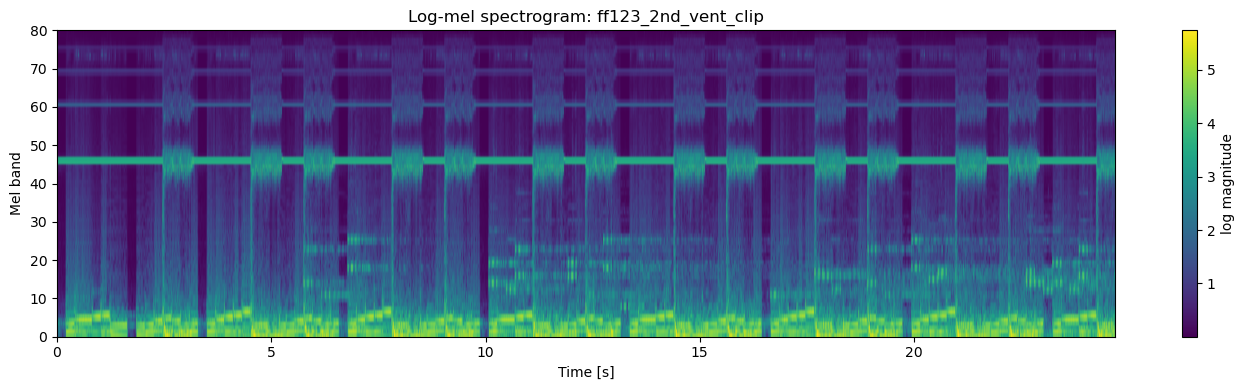

In [5]:
plt.figure(figsize=(14, 4))
plt.imshow(
    mel.log_filtered,
    origin="lower",
    aspect="auto",
    extent=[mel.times[0], mel.times[-1], 0, mel.log_filtered.shape[0]],
)
plt.xlabel("Time [s]")
plt.ylabel("Mel band")
plt.title(f"Log-mel spectrogram: {first_stem}")
plt.colorbar(label="log magnitude")
plt.tight_layout()
plt.show()

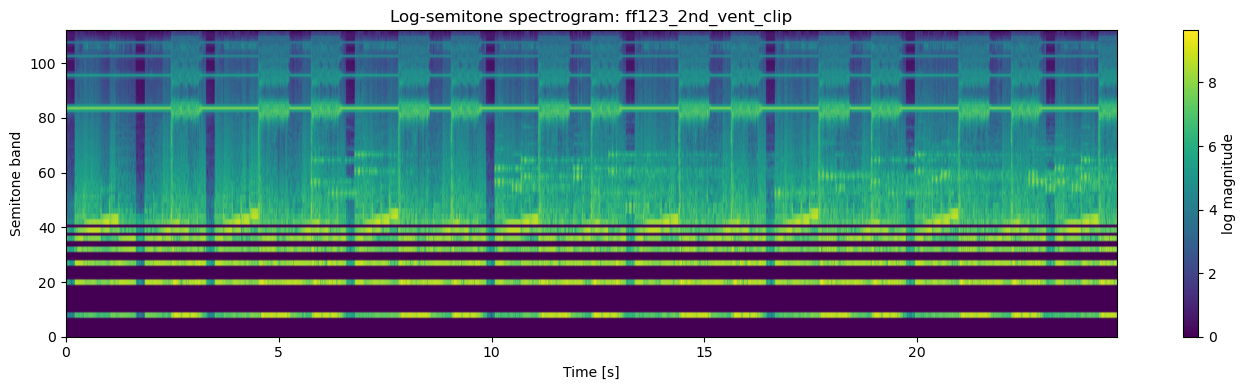

In [6]:
plt.figure(figsize=(14, 4))
plt.imshow(
    semi.log_filtered,
    origin="lower",
    aspect="auto",
    extent=[semi.times[0], semi.times[-1], 0, semi.log_filtered.shape[0]],
)
plt.xlabel("Time [s]")
plt.ylabel("Semitone band")
plt.title(f"Log-semitone spectrogram: {first_stem}")
plt.colorbar(label="log magnitude")
plt.tight_layout()
plt.show()

In [7]:
from src.features import FeatureExtractor

fe = FeatureExtractor()

result = fe.onset_strength(y, method="log_mel_flux")

print(result.method)
print(result.values.shape)
print(result.times.shape)
print(result.values.min(), result.values.max())
print(result.times[:10])

log_mel_flux
(2471,)
(2471,)
0.0 1.0
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


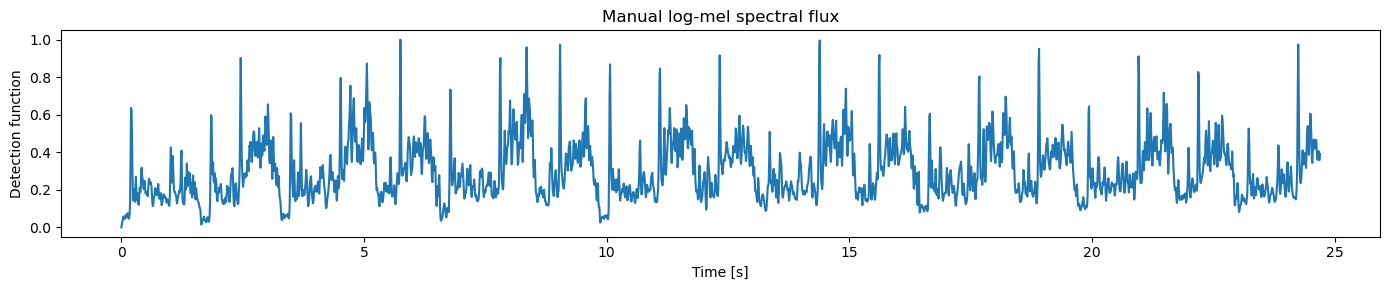

In [8]:
plt.figure(figsize=(14, 3))
plt.plot(result.times, result.values)
plt.xlabel("Time [s]")
plt.ylabel("Detection function")
plt.title("Manual log-mel spectral flux")
plt.tight_layout()
plt.show()

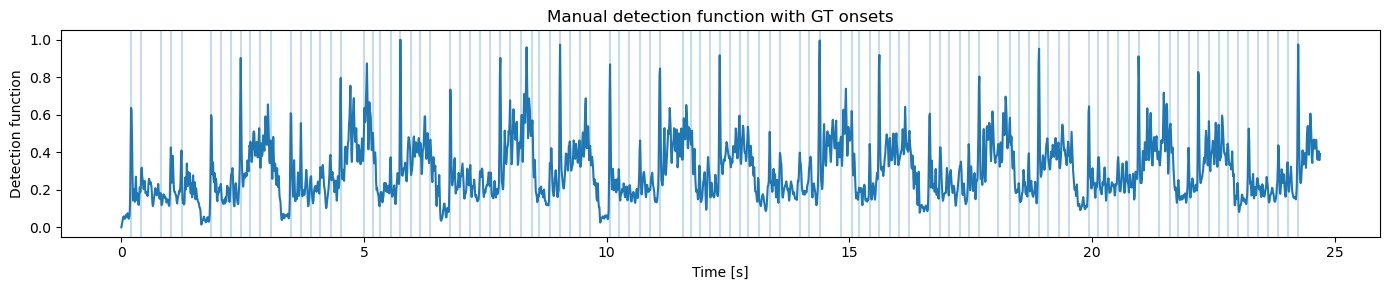

In [9]:
gt_onsets = np.asarray(first_info["onsets"])

plt.figure(figsize=(14, 3))
plt.plot(result.times, result.values, label="manual log-mel flux")

for onset in gt_onsets:
    plt.axvline(onset, alpha=0.25)

plt.xlabel("Time [s]")
plt.ylabel("Detection function")
plt.title("Manual detection function with GT onsets")
plt.tight_layout()
plt.show()

In [6]:
from src.detectors import OnsetDetector, TempoEstimator, BeatTracker, Pipeline

onset_detector = OnsetDetector()
tempo_estimator = TempoEstimator()
beat_tracker = BeatTracker()

onsets = onset_detector.detect(y, sr)
tempos = tempo_estimator.estimate(y, sr)
beats, tempo = beat_tracker.track(y, sr, tempo=tempos[0])

print("Onsets:", onsets[:10], "count:", len(onsets))
print("Tempos:", tempos)
print("Beats:", beats[:10], "count:", len(beats))

Onsets: [0.2  0.3  0.42 0.48 0.57 0.6  0.76 1.02 1.06 1.24] count: 229
Tempos: [29.126, 58.252]
Beats: [ 1.85  3.82  5.92  8.01 10.07 12.09 14.2  16.24 18.24 20.34] count: 12


In [7]:
pipe = Pipeline()
onsets, beats, tempos = pipe.process_file(y, sr)

print("Pipeline onsets:", onsets[:10], len(onsets))
print("Pipeline beats:", beats[:10], len(beats))
print("Pipeline tempos:", tempos)

Pipeline onsets: [0.2  0.3  0.42 0.48 0.57 0.6  0.76 1.02 1.06 1.24] 229
Pipeline beats: [ 0.2   1.35  2.46  3.49  4.67  5.75  6.78  7.9   9.04 10.07] 23
Pipeline tempos: [29.126, 58.252]


In [8]:
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from src.detectors import Pipeline
from src.evaluation import evaluate_events, evaluate_tempo

In [9]:
all_keys = sorted(list(train_data.keys()))

train_keys, val_keys = train_test_split(
    all_keys,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print("Train files:", len(train_keys))
print("Validation files:", len(val_keys))
print("First validation files:", val_keys[:5])

Train files: 101
Validation files: 26
First validation files: ['Media-104917(15.6-25.6)', 'train11', 'ff123_deerhunter', 'Media-106115(15.9-25.9)', 'Media-105905(7.8-17.8)']


In [10]:
pipe = Pipeline()

onset_refs = {}
onset_preds = {}

beat_refs = {}
beat_preds = {}

tempo_refs = {}
tempo_preds = {}

for key in tqdm(val_keys):
    item = train_data[key]

    wav_path = item["wav"]

    y, sr = pp.load_audio(str(wav_path))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_refs[key] = np.asarray(item["onsets"], dtype=float)
    onset_preds[key] = np.asarray(pred_onsets, dtype=float)

    beat_refs[key] = np.asarray(item["beats"], dtype=float)
    beat_preds[key] = np.asarray(pred_beats, dtype=float)

    tempo_refs[key] = item["tempo"]
    tempo_preds[key] = pred_tempos

100%|██████████| 26/26 [00:11<00:00,  2.31it/s]


In [11]:
onset_metrics = evaluate_events(
    onset_refs,
    onset_preds,
    tolerance=0.050,
)

beat_metrics = evaluate_events(
    beat_refs,
    beat_preds,
    tolerance=0.070,
)

tempo_metrics = evaluate_tempo(
    tempo_refs,
    tempo_preds,
    tolerance_percent=8.0,
)

print("Onset metrics")
print("Precision:", round(onset_metrics["precision"], 4))
print("Recall:   ", round(onset_metrics["recall"], 4))
print("F1:       ", round(onset_metrics["f1"], 4))
print("TP/FP/FN: ", onset_metrics["tp"], onset_metrics["fp"], onset_metrics["fn"])

print("\nBeat metrics")
print("Precision:", round(beat_metrics["precision"], 4))
print("Recall:   ", round(beat_metrics["recall"], 4))
print("F1:       ", round(beat_metrics["f1"], 4))
print("TP/FP/FN: ", beat_metrics["tp"], beat_metrics["fp"], beat_metrics["fn"])

print("\nTempo metrics")
print("P-score:", round(tempo_metrics["p_score"], 4))

Onset metrics
Precision: 0.8497
Recall:    0.7979
F1:        0.823
TP/FP/FN:  2029 359 514

Beat metrics
Precision: 0.7355
Recall:    0.7226
F1:        0.729
TP/FP/FN:  659 237 253

Tempo metrics
P-score: 0.6346


In [12]:
thresholds = [0.00, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
smoothing_values = [0.0, 0.5, 1.0]

results = []

for sigma in smoothing_values:
    for th in thresholds:
        config.onset.threshold = th
        config.onset.smoothing_sigma = sigma

        pipe = Pipeline()

        onset_preds_tmp = {}

        for key in tqdm(val_keys, desc=f"th={th}, sigma={sigma}"):
            item = train_data[key]
            y, sr = pp.load_audio(str(item["wav"]))

            pred_onsets, _, _ = pipe.process_file(y, sr)
            onset_preds_tmp[key] = np.asarray(pred_onsets, dtype=float)

        metrics = evaluate_events(
            onset_refs,
            onset_preds_tmp,
            tolerance=0.050,
        )

        results.append({
            "threshold": th,
            "sigma": sigma,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "tp": metrics["tp"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
        })

for r in sorted(results, key=lambda x: x["f1"], reverse=True):
    print(
        f"th={r['threshold']}, sigma={r['sigma']} | "
        f"P={r['precision']:.4f}, R={r['recall']:.4f}, F1={r['f1']:.4f}, "
        f"TP/FP/FN={r['tp']}/{r['fp']}/{r['fn']}"
    )

th=0.1, sigma=1.0: 100%|██████████| 26/26 [00:13<00:00,  1.95it/s]

th=0.05, sigma=1.0 | P=0.8497, R=0.7979, F1=0.8230, TP/FP/FN=2029/359/514
th=0.08, sigma=1.0 | P=0.9379, R=0.7306, F1=0.8214, TP/FP/FN=1858/123/685
th=0.1, sigma=1.0 | P=0.9610, R=0.6874, F1=0.8015, TP/FP/FN=1748/71/795
th=0.1, sigma=0.5 | P=0.8276, R=0.7629, F1=0.7939, TP/FP/FN=1940/404/603
th=0.08, sigma=0.5 | P=0.7684, R=0.8195, F1=0.7931, TP/FP/FN=2084/628/459
th=0.03, sigma=1.0 | P=0.7346, R=0.8423, F1=0.7848, TP/FP/FN=2142/774/401
th=0.1, sigma=0.0 | P=0.7665, R=0.7747, F1=0.7706, TP/FP/FN=1970/600/573
th=0.08, sigma=0.0 | P=0.6928, R=0.8337, F1=0.7567, TP/FP/FN=2120/940/423
th=0.02, sigma=1.0 | P=0.6516, R=0.8612, F1=0.7419, TP/FP/FN=2190/1171/353
th=0.05, sigma=0.5 | P=0.6025, R=0.8852, F1=0.7170, TP/FP/FN=2251/1485/292
th=0.01, sigma=1.0 | P=0.5721, R=0.8801, F1=0.6934, TP/FP/FN=2238/1674/305
th=0.05, sigma=0.0 | P=0.5202, R=0.9013, F1=0.6597, TP/FP/FN=2292/2114/251
th=0.03, sigma=0.5 | P=0.4610, R=0.9312, F1=0.6167, TP/FP/FN=2368/2769/175
th=0.0, sigma=1.0 | P=0.4697, R=0.896

In [13]:
config.onset.threshold = 0.05
config.onset.smoothing_sigma = 1.0
config.onset.method = "log_mel_flux"

pipe = Pipeline()

onset_preds = {}
beat_preds = {}
tempo_preds = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds[key] = pred_tempos

onset_metrics = evaluate_events(onset_refs, onset_preds, tolerance=0.050)
beat_metrics = evaluate_events(beat_refs, beat_preds, tolerance=0.070)
tempo_metrics = evaluate_tempo(tempo_refs, tempo_preds, tolerance_percent=8.0)

print("Onset F1:", round(onset_metrics["f1"], 4))
print("Beat F1:", round(beat_metrics["f1"], 4))
print("Tempo P-score:", round(tempo_metrics["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.07it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [14]:
worst_tempo = sorted(
    tempo_metrics["per_file"].items(),
    key=lambda x: x[1],
)[:26]

for key, score in worst_tempo:
    print(
        key,
        "score:", score,
        "gt:", tempo_refs[key],
        "pred:", tempo_preds[key],
    )

ff123_deerhunter score: 0.0 gt: [28.796259751, 57.5925195021] pred: [88.235, 176.471]
train8 score: 0.0 gt: [74.0, 148.0] pred: [48.78, 97.561]
Media-103505(1.9-11.9) score: 0.0 gt: [50.150109173, 100.300218346] pred: [66.667, 133.333]
Media-104210(2.0-12.0) score: 0.0 gt: [90.160313201, 180.320626402] pred: [58.824, 117.647]
train3 score: 0.0 gt: [76.5, 153.0] pred: [50.0, 100.0]
Media-104917(15.6-25.6) score: 0.5 gt: [102.175790377, 204.351580754] pred: [50.562, 101.124]
ff123_cymbals score: 0.5 gt: [37.5297855442, 75.0595710883] pred: [76.923, 153.846]
train15 score: 0.5 gt: [62.0, 186.0] pred: [92.308, 184.615]
Media-104218(9.3-19.3) score: 0.5 gt: [102.040387046, 204.080774092] pred: [50.847, 101.695]
Media-103714(4.2-14.2) score: 0.5 gt: [88.0145407892, 176.029081578] pred: [43.478, 86.957]
Media-105801(11.0-21.0) score: 0.5 gt: [43.5459298832, 87.0918597665] pred: [83.333, 166.667]
Media-103814(13.8-23.8) score: 0.5 gt: [85.8677884612, 171.735576922] pred: [42.105, 84.211]
lame_

In [15]:
config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.onset.threshold = 0.05
config.onset.smoothing_sigma = 1.0
config.onset.method = "log_mel_flux"

tempo_estimator = TempoEstimator()

tempo_preds_new = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))
    tempo_preds_new[key] = tempo_estimator.estimate(y, sr)

tempo_metrics_new = evaluate_tempo(
    tempo_refs,
    tempo_preds_new,
    tolerance_percent=8.0,
)

print("Old tempo P-score:", round(tempo_metrics["p_score"], 4))
print("New tempo P-score:", round(tempo_metrics_new["p_score"], 4))

100%|██████████| 26/26 [00:01<00:00, 22.27it/s]

Old tempo P-score: 0.6346
New tempo P-score: 0.6346


In [16]:
for key, score in sorted(tempo_metrics_new["per_file"].items(), key=lambda x: x[1])[:15]:
    print(
        key,
        "score:", score,
        "gt:", tempo_refs[key],
        "old:", tempo_preds[key],
        "new:", tempo_preds_new[key],
    )

ff123_deerhunter score: 0.0 gt: [28.796259751, 57.5925195021] old: [88.235, 176.471] new: [88.235, 176.471]
train8 score: 0.0 gt: [74.0, 148.0] old: [48.78, 97.561] new: [48.78, 97.561]
Media-103505(1.9-11.9) score: 0.0 gt: [50.150109173, 100.300218346] old: [66.667, 133.333] new: [66.667, 133.333]
Media-104210(2.0-12.0) score: 0.0 gt: [90.160313201, 180.320626402] old: [58.824, 117.647] new: [58.824, 117.647]
train3 score: 0.0 gt: [76.5, 153.0] old: [50.0, 100.0] new: [50.0, 100.0]
Media-104917(15.6-25.6) score: 0.5 gt: [102.175790377, 204.351580754] old: [50.562, 101.124] new: [50.562, 101.124]
ff123_cymbals score: 0.5 gt: [37.5297855442, 75.0595710883] old: [76.923, 153.846] new: [76.923, 153.846]
train15 score: 0.5 gt: [62.0, 186.0] old: [92.308, 184.615] new: [92.308, 184.615]
Media-104218(9.3-19.3) score: 0.5 gt: [102.040387046, 204.080774092] old: [50.847, 101.695] new: [50.847, 101.695]
Media-103714(4.2-14.2) score: 0.5 gt: [88.0145407892, 176.029081578] old: [43.478, 86.957] n

In [17]:
import inspect
import src.detectors
from src.detectors import TempoEstimator

print(src.detectors.__file__)
print(inspect.getsource(TempoEstimator.estimate))

c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\src\detectors.py
    def estimate(self, y: np.ndarray, sr: int) -> List[float]:
        """
        Estimate one or two tempo guesses using pair-based autocorrelation scoring.

        The challenge tempo annotations often have the form [T, 2T].
        Therefore, this method scores tempo pairs rather than only the strongest
        individual autocorrelation peak.
        """
        result = self.fe.onset_strength(y, method=self.cfg.onset.method)

        bpm_candidates, scores = self.autocorrelation_tempo_candidates(
            result,
            top_k=12,
        )

        if len(bpm_candidates) == 0:
            return [120.0]

        min_bpm = float(self.cfg.beat.tempo_min)
        search_max_bpm = float(self.cfg.beat.tempo_max)

        # We search up to config tempo_max, but avoid returning very high
        # second guesses unless necessary.
        return_max_bpm = min(search_max_bpm, 210.0)

        raw = [
      

In [18]:
key = "Media-105907(0.0-10.0)"
item = train_data[key]

y, sr = pp.load_audio(str(item["wav"]))

tempo_estimator = TempoEstimator()
result = tempo_estimator.fe.onset_strength(y, method=config.onset.method)

bpms, scores = tempo_estimator.autocorrelation_tempo_candidates(result, top_k=12)

print("GT:", tempo_refs[key])
print("Pred:", tempo_estimator.estimate(y, sr))
print("\nRaw autocorrelation candidates:")
for bpm, score in zip(bpms, scores):
    print(f"{bpm:.3f} bpm | score={score:.4f}")

GT: [89.0257909538, 178.051581908]
Pred: [88.235, 176.471]

Raw autocorrelation candidates:
59.406 bpm | score=1.0000
29.557 bpm | score=0.7177
89.552 bpm | score=0.6080
176.471 bpm | score=0.6040
44.444 bpm | score=0.4066
35.503 bpm | score=0.3587
117.647 bpm | score=0.0735
39.735 bpm | score=0.0421


In [19]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import TempoEstimator

In [20]:
key = "Media-105907(0.0-10.0)"
item = train_data[key]

y, sr = pp.load_audio(str(item["wav"]))

tempo_estimator = TempoEstimator()

print("GT:", tempo_refs[key])
print("Pred:", tempo_estimator.estimate(y, sr))

GT: [89.0257909538, 178.051581908]
Pred: [88.235, 176.471]


In [21]:
tempo_preds_new = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))
    tempo_preds_new[key] = tempo_estimator.estimate(y, sr)

tempo_metrics_new = evaluate_tempo(
    tempo_refs,
    tempo_preds_new,
    tolerance_percent=8.0,
)

print("Tempo P-score:", round(tempo_metrics_new["p_score"], 4))

100%|██████████| 26/26 [00:01<00:00, 21.90it/s]

Tempo P-score: 0.6346


In [22]:
comparison = []

for key in val_keys:
    old_score = tempo_metrics["per_file"][key]
    new_score = tempo_metrics_new["per_file"][key]

    comparison.append({
        "key": key,
        "old_score": old_score,
        "new_score": new_score,
        "delta": new_score - old_score,
        "gt": tempo_refs[key],
        "old_pred": tempo_preds[key],
        "new_pred": tempo_preds_new[key],
    })

print("Improved files:")
for row in sorted(comparison, key=lambda x: x["delta"], reverse=True):
    if row["delta"] > 0:
        print(
            row["key"],
            "delta:", row["delta"],
            "gt:", row["gt"],
            "old:", row["old_pred"],
            "new:", row["new_pred"],
        )

print("\nWorse files:")
for row in sorted(comparison, key=lambda x: x["delta"]):
    if row["delta"] < 0:
        print(
            row["key"],
            "delta:", row["delta"],
            "gt:", row["gt"],
            "old:", row["old_pred"],
            "new:", row["new_pred"],
        )

Improved files:

Worse files:


In [23]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import TempoEstimator

tempo_estimator = TempoEstimator()

tempo_preds_new3 = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))
    tempo_preds_new3[key] = tempo_estimator.estimate(y, sr)

tempo_metrics_new3 = evaluate_tempo(
    tempo_refs,
    tempo_preds_new3,
    tolerance_percent=8.0,
)

print("Simple/old P-score:", round(tempo_metrics["p_score"], 4))
print("Pair-based P-score:", round(tempo_metrics_new["p_score"], 4))
print("Conservative P-score:", round(tempo_metrics_new3["p_score"], 4))

100%|██████████| 26/26 [00:01<00:00, 21.90it/s]

Simple/old P-score: 0.6346
Pair-based P-score: 0.6346
Conservative P-score: 0.6346


In [24]:
comparison3 = []

for key in val_keys:
    comparison3.append({
        "key": key,
        "old_score": tempo_metrics["per_file"][key],
        "new_score": tempo_metrics_new3["per_file"][key],
        "delta": tempo_metrics_new3["per_file"][key] - tempo_metrics["per_file"][key],
        "gt": tempo_refs[key],
        "old_pred": tempo_preds[key],
        "new_pred": tempo_preds_new3[key],
    })

print("Improved:")
for row in sorted(comparison3, key=lambda x: x["delta"], reverse=True):
    if row["delta"] > 0:
        print(row["key"], "delta:", row["delta"], "gt:", row["gt"], "old:", row["old_pred"], "new:", row["new_pred"])

print("\nWorse:")
for row in sorted(comparison3, key=lambda x: x["delta"]):
    if row["delta"] < 0:
        print(row["key"], "delta:", row["delta"], "gt:", row["gt"], "old:", row["old_pred"], "new:", row["new_pred"])

Improved:

Worse:


In [25]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import TempoEstimator

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.05
config.onset.smoothing_sigma = 1.0

tempo_estimator = TempoEstimator()

tempo_preds_fixed = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))
    tempo_preds_fixed[key] = tempo_estimator.estimate(y, sr)

tempo_metrics_fixed = evaluate_tempo(
    tempo_refs,
    tempo_preds_fixed,
    tolerance_percent=8.0,
)

print("Tempo P-score:", round(tempo_metrics_fixed["p_score"], 4))

100%|██████████| 26/26 [00:01<00:00, 22.33it/s]

Tempo P-score: 0.6346


In [26]:
key = "Media-105907(0.0-10.0)"
item = train_data[key]
y, sr = pp.load_audio(str(item["wav"]))

print("GT:", tempo_refs[key])
print("Pred:", tempo_estimator.estimate(y, sr))

GT: [89.0257909538, 178.051581908]
Pred: [88.235, 176.471]


In [27]:
comparison_fixed = []

for key in val_keys:
    old_score = tempo_metrics_new["per_file"][key]   # previous pair-based result
    fixed_score = tempo_metrics_fixed["per_file"][key]

    comparison_fixed.append({
        "key": key,
        "old_score": old_score,
        "fixed_score": fixed_score,
        "delta": fixed_score - old_score,
        "gt": tempo_refs[key],
        "old_pred": tempo_preds_new[key],
        "fixed_pred": tempo_preds_fixed[key],
    })

print("Improved after cleanup:")
for row in sorted(comparison_fixed, key=lambda x: x["delta"], reverse=True):
    if row["delta"] > 0:
        print(
            row["key"],
            "delta:", row["delta"],
            "gt:", row["gt"],
            "old:", row["old_pred"],
            "fixed:", row["fixed_pred"],
        )

print("\nWorse after cleanup:")
for row in sorted(comparison_fixed, key=lambda x: x["delta"]):
    if row["delta"] < 0:
        print(
            row["key"],
            "delta:", row["delta"],
            "gt:", row["gt"],
            "old:", row["old_pred"],
            "fixed:", row["fixed_pred"],
        )

Improved after cleanup:

Worse after cleanup:


In [28]:
pipe = Pipeline()

onset_preds_best = {}
beat_preds_best = {}
tempo_preds_best = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_best[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_best[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_best[key] = pred_tempos

onset_metrics_best = evaluate_events(
    onset_refs,
    onset_preds_best,
    tolerance=0.050,
)

beat_metrics_best = evaluate_events(
    beat_refs,
    beat_preds_best,
    tolerance=0.070,
)

tempo_metrics_best = evaluate_tempo(
    tempo_refs,
    tempo_preds_best,
    tolerance_percent=8.0,
)

print("Onset F1:", round(onset_metrics_best["f1"], 4))
print("Beat F1:", round(beat_metrics_best["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_best["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.05it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [29]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

pipe = Pipeline()

onset_preds_best = {}
beat_preds_best = {}
tempo_preds_best = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_best[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_best[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_best[key] = pred_tempos

onset_metrics_best = evaluate_events(
    onset_refs,
    onset_preds_best,
    tolerance=0.050,
)

beat_metrics_best = evaluate_events(
    beat_refs,
    beat_preds_best,
    tolerance=0.070,
)

tempo_metrics_best = evaluate_tempo(
    tempo_refs,
    tempo_preds_best,
    tolerance_percent=8.0,
)

print("Onset F1:", round(onset_metrics_best["f1"], 4))
print("Beat F1:", round(beat_metrics_best["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_best["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.10it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [30]:
def event_f1_for_one_file(ref, pred, tolerance=0.070):
    ref = np.asarray(ref, dtype=float)
    pred = np.asarray(pred, dtype=float)

    if len(ref) == 0 and len(pred) == 0:
        return {
            "precision": 1.0,
            "recall": 1.0,
            "f1": 1.0,
            "tp": 0,
            "fp": 0,
            "fn": 0,
        }

    if len(ref) == 0:
        return {
            "precision": 0.0,
            "recall": 1.0,
            "f1": 0.0,
            "tp": 0,
            "fp": len(pred),
            "fn": 0,
        }

    if len(pred) == 0:
        return {
            "precision": 1.0,
            "recall": 0.0,
            "f1": 0.0,
            "tp": 0,
            "fp": 0,
            "fn": len(ref),
        }

    used_pred = np.zeros(len(pred), dtype=bool)
    tp = 0

    for r in ref:
        distances = np.abs(pred - r)
        distances[used_pred] = np.inf

        best_idx = int(np.argmin(distances))

        if distances[best_idx] <= tolerance:
            used_pred[best_idx] = True
            tp += 1

    fp = len(pred) - tp
    fn = len(ref) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

In [31]:
beat_file_metrics = []

for key in val_keys:
    m = event_f1_for_one_file(
        beat_refs[key],
        beat_preds_best[key],
        tolerance=0.070,
    )

    beat_file_metrics.append({
        "key": key,
        "f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "tp": m["tp"],
        "fp": m["fp"],
        "fn": m["fn"],
        "n_ref": len(beat_refs[key]),
        "n_pred": len(beat_preds_best[key]),
        "tempo_gt": tempo_refs[key],
        "tempo_pred": tempo_preds_best[key],
    })

print("Worst beat files:")
for row in sorted(beat_file_metrics, key=lambda x: x["f1"])[:15]:
    print(
        row["key"],
        "| F1:", round(row["f1"], 4),
        "P:", round(row["precision"], 4),
        "R:", round(row["recall"], 4),
        "TP/FP/FN:", row["tp"], row["fp"], row["fn"],
        "n_ref:", row["n_ref"],
        "n_pred:", row["n_pred"],
        "tempo_gt:", row["tempo_gt"],
        "tempo_pred:", row["tempo_pred"],
    )

Worst beat files:
jpb_jaxx | F1: 0.0 P: 0.0 R: 0.0 TP/FP/FN: 0 14 15 n_ref: 15 n_pred: 14 tempo_gt: [62.7672913344, 125.534582669] tempo_pred: [62.5, 125.0]
Media-103505(1.9-11.9) | F1: 0.3077 P: 0.2609 R: 0.375 TP/FP/FN: 6 17 10 n_ref: 16 n_pred: 23 tempo_gt: [50.150109173, 100.300218346] tempo_pred: [66.667, 133.333]
Media-104218(9.3-19.3) | F1: 0.3137 P: 0.4706 R: 0.2353 TP/FP/FN: 8 9 26 n_ref: 34 n_pred: 17 tempo_gt: [102.040387046, 204.080774092] tempo_pred: [50.847, 101.695]
train8 | F1: 0.3902 P: 0.4898 R: 0.3243 TP/FP/FN: 24 25 50 n_ref: 74 n_pred: 49 tempo_gt: [74.0, 148.0] tempo_pred: [48.78, 97.561]
Media-104210(2.0-12.0) | F1: 0.3922 P: 0.4762 R: 0.3333 TP/FP/FN: 10 11 20 n_ref: 30 n_pred: 21 tempo_gt: [90.160313201, 180.320626402] tempo_pred: [58.824, 117.647]
train3 | F1: 0.3937 P: 0.4902 R: 0.3289 TP/FP/FN: 25 26 51 n_ref: 76 n_pred: 51 tempo_gt: [76.5, 153.0] tempo_pred: [50.0, 100.0]
ff123_deerhunter | F1: 0.4062 P: 0.268 R: 0.8387 TP/FP/FN: 26 71 5 n_ref: 31 n_pred: 9

In [32]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

pipe = Pipeline()

onset_preds_best = {}
beat_preds_best = {}
tempo_preds_best = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_best[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_best[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_best[key] = pred_tempos

onset_metrics_best = evaluate_events(onset_refs, onset_preds_best, tolerance=0.050)
beat_metrics_best = evaluate_events(beat_refs, beat_preds_best, tolerance=0.070)
tempo_metrics_best = evaluate_tempo(tempo_refs, tempo_preds_best, tolerance_percent=8.0)

print("Onset F1:", round(onset_metrics_best["f1"], 4))
print("Beat F1:", round(beat_metrics_best["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_best["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.08it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [33]:
beat_file_metrics = []

for key in val_keys:
    m = event_f1_for_one_file(
        beat_refs[key],
        beat_preds_best[key],
        tolerance=0.070,
    )

    beat_file_metrics.append({
        "key": key,
        "f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "tp": m["tp"],
        "fp": m["fp"],
        "fn": m["fn"],
        "n_ref": len(beat_refs[key]),
        "n_pred": len(beat_preds_best[key]),
        "tempo_gt": tempo_refs[key],
        "tempo_pred": tempo_preds_best[key],
    })

print("Beat-count mismatch cases:")
for row in sorted(beat_file_metrics, key=lambda x: x["f1"]):
    ratio = row["n_pred"] / row["n_ref"] if row["n_ref"] > 0 else 0

    if ratio < 0.7 or ratio > 1.4:
        print(
            row["key"],
            "| F1:", round(row["f1"], 4),
            "n_ref:", row["n_ref"],
            "n_pred:", row["n_pred"],
            "ratio:", round(ratio, 2),
            "tempo_gt:", row["tempo_gt"],
            "tempo_pred:", row["tempo_pred"],
        )

Beat-count mismatch cases:
Media-103505(1.9-11.9) | F1: 0.3077 n_ref: 16 n_pred: 23 ratio: 1.44 tempo_gt: [50.150109173, 100.300218346] tempo_pred: [66.667, 133.333]
Media-104218(9.3-19.3) | F1: 0.3137 n_ref: 34 n_pred: 17 ratio: 0.5 tempo_gt: [102.040387046, 204.080774092] tempo_pred: [50.847, 101.695]
train8 | F1: 0.3902 n_ref: 74 n_pred: 49 ratio: 0.66 tempo_gt: [74.0, 148.0] tempo_pred: [48.78, 97.561]
train3 | F1: 0.3937 n_ref: 76 n_pred: 51 ratio: 0.67 tempo_gt: [76.5, 153.0] tempo_pred: [50.0, 100.0]
ff123_deerhunter | F1: 0.4062 n_ref: 31 n_pred: 97 ratio: 3.13 tempo_gt: [28.796259751, 57.5925195021] tempo_pred: [88.235, 176.471]
ff123_bloodline | F1: 0.4167 n_ref: 31 n_pred: 17 ratio: 0.55 tempo_gt: [59.0161301804, 118.032260361] tempo_pred: [30.151, 60.302]
Media-103714(4.2-14.2) | F1: 0.5 n_ref: 29 n_pred: 15 ratio: 0.52 tempo_gt: [88.0145407892, 176.029081578] tempo_pred: [43.478, 86.957]
Media-104917(15.6-25.6) | F1: 0.6154 n_ref: 34 n_pred: 18 ratio: 0.53 tempo_gt: [102.1

In [34]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

pipe = Pipeline()

onset_preds_best = {}
beat_preds_best = {}
tempo_preds_best = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_best[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_best[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_best[key] = pred_tempos

onset_metrics_best = evaluate_events(onset_refs, onset_preds_best, tolerance=0.050)
beat_metrics_best = evaluate_events(beat_refs, beat_preds_best, tolerance=0.070)
tempo_metrics_best = evaluate_tempo(tempo_refs, tempo_preds_best, tolerance_percent=8.0)

print("Onset F1:", round(onset_metrics_best["f1"], 4))
print("Beat F1:", round(beat_metrics_best["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_best["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.01it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [35]:
import importlib
import numpy as np
from tqdm import tqdm

import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

pipe = Pipeline()

onset_preds_dp = {}
beat_preds_dp = {}
tempo_preds_dp = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_dp[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_dp[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_dp[key] = pred_tempos

onset_metrics_dp = evaluate_events(
    onset_refs,
    onset_preds_dp,
    tolerance=0.050,
)

beat_metrics_dp = evaluate_events(
    beat_refs,
    beat_preds_dp,
    tolerance=0.070,
)

tempo_metrics_dp = evaluate_tempo(
    tempo_refs,
    tempo_preds_dp,
    tolerance_percent=8.0,
)

print("Onset F1:", round(onset_metrics_dp["f1"], 4))
print("Beat F1:", round(beat_metrics_dp["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_dp["p_score"], 4))

100%|██████████| 26/26 [00:12<00:00,  2.02it/s]

Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [36]:
print("Previous best:")
print("Onset F1:      0.8141")
print("Beat F1:       0.6433")
print("Tempo P-score: 0.6346")

print("\nDP version:")
print("Onset F1:", round(onset_metrics_dp["f1"], 4))
print("Beat F1:", round(beat_metrics_dp["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_dp["p_score"], 4))

Previous best:
Onset F1:      0.8141
Beat F1:       0.6433
Tempo P-score: 0.6346

DP version:
Onset F1: 0.823
Beat F1: 0.729
Tempo P-score: 0.6346


In [37]:
def diagnose_beat_method(pipe, y, sr):
    tempos = pipe.tempo_estimator.estimate(y, sr)

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method=pipe.cfg.onset.method,
    )

    rows = []

    for tempo in tempos:
        for method in ["grid", "dp"]:
            if method == "grid":
                beats, _ = pipe.beat_tracker.track(y, sr, tempo=tempo)
            else:
                beats, _ = pipe.beat_tracker.track_dynamic_programming(
                    y,
                    sr,
                    tempo=tempo,
                    transition_width=0.20,
                    transition_lambda=0.8,
                    activation_power=1.5,
                )

            if len(beats) == 0:
                score = -np.inf
            else:
                beat_frames = np.round(
                    beats * detection_result.sr / detection_result.hop_length
                ).astype(int)

                beat_frames = beat_frames[
                    (beat_frames >= 0) & (beat_frames < len(detection_result.values))
                ]

                if len(beat_frames) == 0:
                    score = -np.inf
                else:
                    score = np.sum(detection_result.values[beat_frames])
                    score = score / np.sqrt(len(beat_frames))

            rows.append({
                "tempo": tempo,
                "method": method,
                "n_beats": len(beats),
                "score": score,
            })

    return rows

In [38]:
for key in ["jpb_jaxx", "ff123_bloodline", "train3", "Media-104218(9.3-19.3)"]:
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    print("\n", key)
    print("GT tempo:", tempo_refs[key])
    print("Pred tempo:", tempo_preds_dp[key])

    rows = diagnose_beat_method(pipe, y, sr)

    for row in sorted(rows, key=lambda x: x["score"], reverse=True):
        print(row)


 jpb_jaxx
GT tempo: [62.7672913344, 125.534582669]
Pred tempo: [62.5, 125.0]
{'tempo': 125.0, 'method': 'grid', 'n_beats': 14, 'score': np.float64(2.7368712813750573)}
{'tempo': 125.0, 'method': 'dp', 'n_beats': 15, 'score': np.float64(2.6697822228496126)}
{'tempo': 62.5, 'method': 'dp', 'n_beats': 8, 'score': np.float64(2.0816874702687262)}
{'tempo': 62.5, 'method': 'grid', 'n_beats': 7, 'score': np.float64(2.0265835016882234)}

 ff123_bloodline
GT tempo: [59.0161301804, 118.032260361]
Pred tempo: [30.151, 60.302]
{'tempo': 60.302, 'method': 'dp', 'n_beats': 16, 'score': np.float64(1.6637320518493652)}
{'tempo': 60.302, 'method': 'grid', 'n_beats': 16, 'score': np.float64(1.5024144649505615)}
{'tempo': 30.151, 'method': 'dp', 'n_beats': 9, 'score': np.float64(1.406510829925537)}
{'tempo': 30.151, 'method': 'grid', 'n_beats': 8, 'score': np.float64(1.1880925169516616)}

 train3
GT tempo: [76.5, 153.0]
Pred tempo: [50.0, 100.0]
{'tempo': 100.0, 'method': 'dp', 'n_beats': 52, 'score': n

In [39]:
transition_width_values = [0.10, 0.15, 0.20, 0.25, 0.30]
transition_lambda_values = [0.3, 0.5, 0.8, 1.2]
activation_power_values = [1.0, 1.5, 2.0]

In [40]:
transition_width_values = [0.10, 0.15, 0.20, 0.25, 0.30]

dp_sweep = []

for width in transition_width_values:
    beat_preds_tmp = {}

    for key in tqdm(val_keys, desc=f"width={width}"):
        item = train_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        tempos = pipe.tempo_estimator.estimate(y, sr)
        detection_result = pipe.beat_tracker.fe.onset_strength(
            y,
            method=config.onset.method,
        )

        best_beats = np.array([])
        best_score = -np.inf

        for tempo in tempos:
            beats, _ = pipe.beat_tracker.track_dynamic_programming(
                y,
                sr,
                tempo=tempo,
                transition_width=width,
                transition_lambda=0.8,
                activation_power=1.5,
            )

            if len(beats) == 0:
                continue

            beat_frames = np.round(
                beats * detection_result.sr / detection_result.hop_length
            ).astype(int)

            beat_frames = beat_frames[
                (beat_frames >= 0) & (beat_frames < len(detection_result.values))
            ]

            if len(beat_frames) == 0:
                continue

            score = np.sum(detection_result.values[beat_frames])
            score = score / np.sqrt(len(beat_frames))

            if score > best_score:
                best_score = score
                best_beats = beats

        beat_preds_tmp[key] = np.asarray(best_beats, dtype=float)

    m = evaluate_events(
        beat_refs,
        beat_preds_tmp,
        tolerance=0.070,
    )

    dp_sweep.append({
        "width": width,
        "beat_f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
    })

for row in sorted(dp_sweep, key=lambda x: x["beat_f1"], reverse=True):
    print(row)

width=0.3: 100%|██████████| 26/26 [00:11<00:00,  2.22it/s]

{'width': 0.1, 'beat_f1': 0.7239467849223947, 'precision': 0.7320627802690582, 'recall': 0.7160087719298246}
{'width': 0.15, 'beat_f1': 0.7149972329828446, 'precision': 0.7217877094972067, 'recall': 0.7083333333333334}
{'width': 0.2, 'beat_f1': 0.7096418732782369, 'precision': 0.7131782945736435, 'recall': 0.706140350877193}
{'width': 0.3, 'beat_f1': 0.6888283378746595, 'precision': 0.6847237269772481, 'recall': 0.6929824561403509}
{'width': 0.25, 'beat_f1': 0.6838638858397365, 'precision': 0.6846153846153846, 'recall': 0.6831140350877193}


In [41]:
lambda_values = [0.1, 0.2, 0.3, 0.5, 0.8, 1.2, 1.6, 2.0]

lambda_sweep = []

for lam in lambda_values:
    beat_preds_tmp = {}

    for key in tqdm(val_keys, desc=f"lambda={lam}"):
        item = train_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        tempos = pipe.tempo_estimator.estimate(y, sr)
        detection_result = pipe.beat_tracker.fe.onset_strength(
            y,
            method=config.onset.method,
        )

        best_beats = np.array([])
        best_score = -np.inf

        for tempo in tempos:
            beats, _ = pipe.beat_tracker.track_dynamic_programming(
                y,
                sr,
                tempo=tempo,
                transition_width=0.10,
                transition_lambda=lam,
                activation_power=1.5,
            )

            if len(beats) == 0:
                continue

            beat_frames = np.round(
                beats * detection_result.sr / detection_result.hop_length
            ).astype(int)

            beat_frames = beat_frames[
                (beat_frames >= 0) & (beat_frames < len(detection_result.values))
            ]

            if len(beat_frames) == 0:
                continue

            score = np.sum(detection_result.values[beat_frames])
            score = score / np.sqrt(len(beat_frames))

            if score > best_score:
                best_score = score
                best_beats = beats

        beat_preds_tmp[key] = np.asarray(best_beats, dtype=float)

    m = evaluate_events(
        beat_refs,
        beat_preds_tmp,
        tolerance=0.070,
    )

    lambda_sweep.append({
        "lambda": lam,
        "beat_f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
    })

for row in sorted(lambda_sweep, key=lambda x: x["beat_f1"], reverse=True):
    print(row)

lambda=2.0: 100%|██████████| 26/26 [00:07<00:00,  3.26it/s]

{'lambda': 2.0, 'beat_f1': 0.7283813747228381, 'precision': 0.7365470852017937, 'recall': 0.7203947368421053}
{'lambda': 1.6, 'beat_f1': 0.7261640798226163, 'precision': 0.734304932735426, 'recall': 0.7182017543859649}
{'lambda': 0.5, 'beat_f1': 0.7239467849223947, 'precision': 0.7320627802690582, 'recall': 0.7160087719298246}
{'lambda': 0.8, 'beat_f1': 0.7239467849223947, 'precision': 0.7320627802690582, 'recall': 0.7160087719298246}
{'lambda': 1.2, 'beat_f1': 0.7239467849223947, 'precision': 0.7320627802690582, 'recall': 0.7160087719298246}
{'lambda': 0.1, 'beat_f1': 0.7228381374722839, 'precision': 0.7309417040358744, 'recall': 0.7149122807017544}
{'lambda': 0.2, 'beat_f1': 0.7228381374722839, 'precision': 0.7309417040358744, 'recall': 0.7149122807017544}
{'lambda': 0.3, 'beat_f1': 0.7228381374722839, 'precision': 0.7309417040358744, 'recall': 0.7149122807017544}


In [42]:
power_values = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]

power_sweep = []

for power in power_values:
    beat_preds_tmp = {}

    for key in tqdm(val_keys, desc=f"power={power}"):
        item = train_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        tempos = pipe.tempo_estimator.estimate(y, sr)
        detection_result = pipe.beat_tracker.fe.onset_strength(
            y,
            method=config.onset.method,
        )

        best_beats = np.array([])
        best_score = -np.inf

        for tempo in tempos:
            beats, _ = pipe.beat_tracker.track_dynamic_programming(
                y,
                sr,
                tempo=tempo,
                transition_width=0.10,
                transition_lambda=2.0,
                activation_power=power,
            )

            if len(beats) == 0:
                continue

            beat_frames = np.round(
                beats * detection_result.sr / detection_result.hop_length
            ).astype(int)

            beat_frames = beat_frames[
                (beat_frames >= 0) & (beat_frames < len(detection_result.values))
            ]

            if len(beat_frames) == 0:
                continue

            score = np.sum(detection_result.values[beat_frames])
            score = score / np.sqrt(len(beat_frames))

            if score > best_score:
                best_score = score
                best_beats = beats

        beat_preds_tmp[key] = np.asarray(best_beats, dtype=float)

    m = evaluate_events(
        beat_refs,
        beat_preds_tmp,
        tolerance=0.070,
    )

    power_sweep.append({
        "power": power,
        "beat_f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
    })

for row in sorted(power_sweep, key=lambda x: x["beat_f1"], reverse=True):
    print(row)

power=3.0: 100%|██████████| 26/26 [00:07<00:00,  3.69it/s]

{'power': 1.0, 'beat_f1': 0.7321921590281613, 'precision': 0.7374860956618465, 'recall': 0.7269736842105263}
{'power': 1.2, 'beat_f1': 0.7318960751796573, 'precision': 0.738015607580825, 'recall': 0.7258771929824561}
{'power': 2.0, 'beat_f1': 0.7314349525404802, 'precision': 0.745164960182025, 'recall': 0.7182017543859649}
{'power': 1.5, 'beat_f1': 0.7283813747228381, 'precision': 0.7365470852017937, 'recall': 0.7203947368421053}
{'power': 1.8, 'beat_f1': 0.7279821627647716, 'precision': 0.7403628117913832, 'recall': 0.7160087719298246}
{'power': 3.0, 'beat_f1': 0.727780883174958, 'precision': 0.74230330672748, 'recall': 0.7138157894736842}
{'power': 2.5, 'beat_f1': 0.7236180904522612, 'precision': 0.7372013651877133, 'recall': 0.7105263157894737}


In [43]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline, OnsetDetector

In [44]:
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.05
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

onset_detector = OnsetDetector()

onset_preds_median = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))
    onset_preds_median[key] = onset_detector.detect(y, sr)

onset_metrics_median = evaluate_events(
    onset_refs,
    onset_preds_median,
    tolerance=0.050,
)

print("Onset precision:", round(onset_metrics_median["precision"], 4))
print("Onset recall:", round(onset_metrics_median["recall"], 4))
print("Onset F1:", round(onset_metrics_median["f1"], 4))
print("TP/FP/FN:", onset_metrics_median["tp"], onset_metrics_median["fp"], onset_metrics_median["fn"])

100%|██████████| 26/26 [00:03<00:00,  8.28it/s]


Onset precision: 0.8497
Onset recall: 0.7979
Onset F1: 0.823
TP/FP/FN: 2029 359 514


In [45]:
thresholds = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]
smoothing_values = [0.5, 1.0, 1.5]

median_results = []

for sigma in smoothing_values:
    for th in thresholds:
        config.onset.threshold = th
        config.onset.smoothing_sigma = sigma
        config.onset.method = "log_mel_flux"

        onset_detector = OnsetDetector()
        onset_preds_tmp = {}

        for key in tqdm(val_keys, desc=f"th={th}, sigma={sigma}"):
            item = train_data[key]
            y, sr = pp.load_audio(str(item["wav"]))
            onset_preds_tmp[key] = onset_detector.detect(y, sr)

        metrics = evaluate_events(
            onset_refs,
            onset_preds_tmp,
            tolerance=0.050,
        )

        median_results.append({
            "threshold": th,
            "sigma": sigma,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "tp": metrics["tp"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
        })

for row in sorted(median_results, key=lambda x: x["f1"], reverse=True):
    print(
        f"th={row['threshold']}, sigma={row['sigma']} | "
        f"P={row['precision']:.4f}, R={row['recall']:.4f}, F1={row['f1']:.4f}, "
        f"TP/FP/FN={row['tp']}/{row['fp']}/{row['fn']}"
    )

th=0.1, sigma=1.5: 100%|██████████| 26/26 [00:03<00:00,  6.86it/s]

th=0.06, sigma=1.0 | P=0.8904, R=0.7731, F1=0.8276, TP/FP/FN=1966/242/577
th=0.05, sigma=1.0 | P=0.8497, R=0.7979, F1=0.8230, TP/FP/FN=2029/359/514
th=0.08, sigma=1.0 | P=0.9379, R=0.7306, F1=0.8214, TP/FP/FN=1858/123/685
th=0.04, sigma=1.5 | P=0.8933, R=0.7440, F1=0.8118, TP/FP/FN=1892/226/651
th=0.05, sigma=1.5 | P=0.9262, R=0.7200, F1=0.8102, TP/FP/FN=1831/146/712
th=0.04, sigma=1.0 | P=0.7981, R=0.8191, F1=0.8085, TP/FP/FN=2083/527/460
th=0.03, sigma=1.5 | P=0.8505, R=0.7648, F1=0.8054, TP/FP/FN=1945/342/598
th=0.06, sigma=1.5 | P=0.9497, R=0.6972, F1=0.8041, TP/FP/FN=1773/94/770
th=0.1, sigma=1.0 | P=0.9610, R=0.6874, F1=0.8015, TP/FP/FN=1748/71/795
th=0.1, sigma=0.5 | P=0.8276, R=0.7629, F1=0.7939, TP/FP/FN=1940/404/603
th=0.08, sigma=0.5 | P=0.7684, R=0.8195, F1=0.7931, TP/FP/FN=2084/628/459
th=0.02, sigma=1.5 | P=0.8026, R=0.7833, F1=0.7928, TP/FP/FN=1992/490/551
th=0.08, sigma=1.5 | P=0.9712, R=0.6622, F1=0.7875, TP/FP/FN=1684/50/859
th=0.03, sigma=1.0 | P=0.7346, R=0.8423, F1

In [47]:
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

In [49]:
import importlib
import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0

pipe = Pipeline()

onset_preds_final = {}
beat_preds_final = {}
tempo_preds_final = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_final[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_final[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_final[key] = pred_tempos

onset_metrics_final = evaluate_events(
    onset_refs,
    onset_preds_final,
    tolerance=0.050,
)

beat_metrics_final = evaluate_events(
    beat_refs,
    beat_preds_final,
    tolerance=0.070,
)

tempo_metrics_final = evaluate_tempo(
    tempo_refs,
    tempo_preds_final,
    tolerance_percent=8.0,
)

print("Onset F1:", round(onset_metrics_final["f1"], 4))
print("Beat F1:", round(beat_metrics_final["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_final["p_score"], 4))
print("Onset TP/FP/FN:", onset_metrics_final["tp"], onset_metrics_final["fp"], onset_metrics_final["fn"])

100%|██████████| 26/26 [00:09<00:00,  2.66it/s]

Onset F1: 0.8276
Beat F1: 0.7322
Tempo P-score: 0.6346
Onset TP/FP/FN: 1966 242 577


In [50]:
beat_weight_configs = [
    (0.60, 0.30, 0.10),
    (0.50, 0.35, 0.15),
    (0.40, 0.40, 0.20),
    (0.35, 0.45, 0.20),
    (0.30, 0.50, 0.20),
    (0.25, 0.50, 0.25),
]

In [51]:
transition_width = 0.10
transition_lambda = 2.0
activation_power = 1.0

In [52]:
print("Onset F1:", round(onset_metrics_final["f1"], 4))
print("Beat F1:", round(beat_metrics_final["f1"], 4))
print("Tempo P-score:", round(tempo_metrics_final["p_score"], 4))

Onset F1: 0.8276
Beat F1: 0.7322
Tempo P-score: 0.6346


In [53]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors
import src.config

importlib.reload(src.config)
importlib.reload(src.features)
importlib.reload(src.detectors)

from src.config import config
from src.detectors import Pipeline

config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0

beat_weight_configs = [
    (0.70, 0.20, 0.10),
    (0.60, 0.30, 0.10),
    (0.50, 0.35, 0.15),
    (0.40, 0.40, 0.20),
    (0.35, 0.45, 0.20),
    (0.30, 0.50, 0.20),
    (0.25, 0.50, 0.25),
    (0.20, 0.55, 0.25),
]

weight_sweep_results = []

for weights in beat_weight_configs:
    config.beat.beat_flux_weights = weights

    pipe = Pipeline()

    onset_preds_tmp = {}
    beat_preds_tmp = {}
    tempo_preds_tmp = {}

    for key in tqdm(val_keys, desc=f"weights={weights}"):
        item = train_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

        onset_preds_tmp[key] = np.asarray(pred_onsets, dtype=float)
        beat_preds_tmp[key] = np.asarray(pred_beats, dtype=float)
        tempo_preds_tmp[key] = pred_tempos

    onset_m = evaluate_events(onset_refs, onset_preds_tmp, tolerance=0.050)
    beat_m = evaluate_events(beat_refs, beat_preds_tmp, tolerance=0.070)
    tempo_m = evaluate_tempo(tempo_refs, tempo_preds_tmp, tolerance_percent=8.0)

    weight_sweep_results.append({
        "weights": weights,
        "onset_f1": onset_m["f1"],
        "beat_f1": beat_m["f1"],
        "beat_precision": beat_m["precision"],
        "beat_recall": beat_m["recall"],
        "tempo_p": tempo_m["p_score"],
    })

for row in sorted(weight_sweep_results, key=lambda x: x["beat_f1"], reverse=True):
    print(
        "weights=", row["weights"],
        "| Beat F1:", round(row["beat_f1"], 4),
        "P:", round(row["beat_precision"], 4),
        "R:", round(row["beat_recall"], 4),
        "| Onset F1:", round(row["onset_f1"], 4),
        "| Tempo P:", round(row["tempo_p"], 4),
    )

weights=(0.2, 0.55, 0.25): 100%|██████████| 26/26 [00:12<00:00,  2.09it/s]

weights= (0.4, 0.4, 0.2) | Beat F1: 0.7481 P: 0.7539 R: 0.7423 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.6, 0.3, 0.1) | Beat F1: 0.7436 P: 0.7494 R: 0.7379 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.7, 0.2, 0.1) | Beat F1: 0.741 P: 0.7464 R: 0.7357 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.5, 0.35, 0.15) | Beat F1: 0.7403 P: 0.7461 R: 0.7346 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.35, 0.45, 0.2) | Beat F1: 0.7326 P: 0.7383 R: 0.727 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.3, 0.5, 0.2) | Beat F1: 0.726 P: 0.7316 R: 0.7204 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.25, 0.5, 0.25) | Beat F1: 0.726 P: 0.7316 R: 0.7204 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.2, 0.55, 0.25) | Beat F1: 0.7028 P: 0.7082 R: 0.6974 | Onset F1: 0.8276 | Tempo P: 0.6346


In [54]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors
import src.config

importlib.reload(src.config)
importlib.reload(src.features)
importlib.reload(src.detectors)

from src.config import config
from src.detectors import Pipeline

config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0

beat_weight_configs_fine = [
    (0.45, 0.40, 0.15),
    (0.45, 0.35, 0.20),
    (0.40, 0.45, 0.15),
    (0.40, 0.40, 0.20),
    (0.40, 0.35, 0.25),
    (0.35, 0.45, 0.20),
    (0.35, 0.40, 0.25),
    (0.50, 0.30, 0.20),
    (0.50, 0.35, 0.15),
]

weight_sweep_results = []

for weights in beat_weight_configs_fine:
    config.beat.beat_flux_weights = weights

    pipe = Pipeline()

    onset_preds_tmp = {}
    beat_preds_tmp = {}
    tempo_preds_tmp = {}

    for key in tqdm(val_keys, desc=f"weights={weights}"):
        item = train_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

        onset_preds_tmp[key] = np.asarray(pred_onsets, dtype=float)
        beat_preds_tmp[key] = np.asarray(pred_beats, dtype=float)
        tempo_preds_tmp[key] = pred_tempos

    onset_m = evaluate_events(onset_refs, onset_preds_tmp, tolerance=0.050)
    beat_m = evaluate_events(beat_refs, beat_preds_tmp, tolerance=0.070)
    tempo_m = evaluate_tempo(tempo_refs, tempo_preds_tmp, tolerance_percent=8.0)

    weight_sweep_results.append({
        "weights": weights,
        "onset_f1": onset_m["f1"],
        "beat_f1": beat_m["f1"],
        "beat_precision": beat_m["precision"],
        "beat_recall": beat_m["recall"],
        "tempo_p": tempo_m["p_score"],
    })

for row in sorted(weight_sweep_results, key=lambda x: x["beat_f1"], reverse=True):
    print(
        "weights=", row["weights"],
        "| Beat F1:", round(row["beat_f1"], 4),
        "P:", round(row["beat_precision"], 4),
        "R:", round(row["beat_recall"], 4),
        "| Onset F1:", round(row["onset_f1"], 4),
        "| Tempo P:", round(row["tempo_p"], 4),
    )

weights=(0.5, 0.35, 0.15): 100%|██████████| 26/26 [00:11<00:00,  2.20it/s]

weights= (0.45, 0.4, 0.15) | Beat F1: 0.7492 P: 0.755 R: 0.7434 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.4, 0.45, 0.15) | Beat F1: 0.7492 P: 0.755 R: 0.7434 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.4, 0.35, 0.25) | Beat F1: 0.7488 P: 0.7542 R: 0.7434 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.4, 0.4, 0.2) | Beat F1: 0.7481 P: 0.7539 R: 0.7423 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.5, 0.3, 0.2) | Beat F1: 0.7403 P: 0.7461 R: 0.7346 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.5, 0.35, 0.15) | Beat F1: 0.7403 P: 0.7461 R: 0.7346 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.45, 0.35, 0.2) | Beat F1: 0.7392 P: 0.745 R: 0.7336 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.35, 0.45, 0.2) | Beat F1: 0.7326 P: 0.7383 R: 0.727 | Onset F1: 0.8276 | Tempo P: 0.6346
weights= (0.35, 0.4, 0.25) | Beat F1: 0.7311 P: 0.7364 R: 0.7259 | Onset F1: 0.8276 | Tempo P: 0.6346


In [55]:
from pathlib import Path
import numpy as np

def read_float_list(path):
    values = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                values.extend([float(x) for x in line.split()])
    return values


def load_tempobeat_extra(extra_dir):
    extra_dir = Path(extra_dir)

    data = {}

    wav_files = sorted(extra_dir.glob("*.wav"))

    for wav_path in wav_files:
        stem = wav_path.stem

        beats_path = extra_dir / f"{stem}.beats.gt"
        tempo_path = extra_dir / f"{stem}.tempo.gt"

        if not beats_path.exists() or not tempo_path.exists():
            continue

        data[stem] = {
            "wav": wav_path,
            "beats": np.asarray(read_float_list(beats_path), dtype=float),
            "tempo": read_float_list(tempo_path),
        }

    return data

In [56]:
extra_tempobeats_dir = config.paths.data_processed_dir / "train_extra_tempobeats"

extra_tb_data = load_tempobeat_extra(extra_tempobeats_dir)

print("Loaded extra tempo/beat files:", len(extra_tb_data))
print("Example keys:", list(extra_tb_data.keys())[:5])

Loaded extra tempo/beat files: 696
Example keys: ['ballroom_Albums-AnaBelen_Veneo-01', 'ballroom_Albums-AnaBelen_Veneo-02', 'ballroom_Albums-AnaBelen_Veneo-03', 'ballroom_Albums-AnaBelen_Veneo-11', 'ballroom_Albums-AnaBelen_Veneo-13']


In [57]:
print(config.paths.data_processed_dir)
print([p.name for p in config.paths.data_processed_dir.iterdir() if p.is_dir()])

c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\data\processed
['test', 'train', 'train_extra_onsets', 'train_extra_tempobeats']


In [58]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline

config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)

pipe = Pipeline()

extra_beat_refs = {}
extra_beat_preds = {}

extra_tempo_refs = {}
extra_tempo_preds = {}

for key in tqdm(sorted(extra_tb_data.keys())):
    item = extra_tb_data[key]

    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    extra_beat_refs[key] = np.asarray(item["beats"], dtype=float)
    extra_beat_preds[key] = np.asarray(pred_beats, dtype=float)

    extra_tempo_refs[key] = item["tempo"]
    extra_tempo_preds[key] = pred_tempos

extra_beat_metrics = evaluate_events(
    extra_beat_refs,
    extra_beat_preds,
    tolerance=0.070,
)

extra_tempo_metrics = evaluate_tempo(
    extra_tempo_refs,
    extra_tempo_preds,
    tolerance_percent=8.0,
)

print("Extra beat F1:", round(extra_beat_metrics["f1"], 4))
print("Extra beat precision:", round(extra_beat_metrics["precision"], 4))
print("Extra beat recall:", round(extra_beat_metrics["recall"], 4))
print("Extra tempo P-score:", round(extra_tempo_metrics["p_score"], 4))
print("Beat TP/FP/FN:", extra_beat_metrics["tp"], extra_beat_metrics["fp"], extra_beat_metrics["fn"])

100%|██████████| 696/696 [09:36<00:00,  1.21it/s]


Extra beat F1: 0.5156
Extra beat precision: 0.685
Extra beat recall: 0.4133
Extra tempo P-score: 0.8
Beat TP/FP/FN: 36648 16850 52020


In [59]:
import random

random.seed(42)
extra_keys = sorted(extra_tb_data.keys())
extra_subset_keys = random.sample(extra_keys, 100)

In [60]:
extra_subset_file_metrics = []

for key in tqdm(extra_subset_keys):
    item = extra_tb_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    _, pred_beats, pred_tempos = pipe.process_file(y, sr)

    m = event_f1_for_one_file(
        item["beats"],
        pred_beats,
        tolerance=0.070,
    )

    n_ref = len(item["beats"])
    n_pred = len(pred_beats)
    ratio = n_pred / n_ref if n_ref > 0 else 0.0

    extra_subset_file_metrics.append({
        "key": key,
        "f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "n_ref": n_ref,
        "n_pred": n_pred,
        "ratio": ratio,
        "tempo_gt": item["tempo"],
        "tempo_pred": pred_tempos,
    })

print("Worst extra subset files:")
for row in sorted(extra_subset_file_metrics, key=lambda x: x["f1"])[:20]:
    print(
        row["key"],
        "| F1:", round(row["f1"], 4),
        "P:", round(row["precision"], 4),
        "R:", round(row["recall"], 4),
        "n_ref:", row["n_ref"],
        "n_pred:", row["n_pred"],
        "ratio:", round(row["ratio"], 2),
        "tempo_gt:", row["tempo_gt"],
        "tempo_pred:", row["tempo_pred"],
    )

100%|██████████| 100/100 [01:08<00:00,  1.46it/s]

Worst extra subset files:
ballroom_Media-103606 | F1: 0.1781 P: 0.1912 R: 0.1667 n_ref: 78 n_pred: 68 ratio: 0.87 tempo_gt: [102.04] tempo_pred: [67.797, 135.593]
ballroom_Albums-Latino_Latino-03 | F1: 0.1893 P: 0.2319 R: 0.16 n_ref: 100 n_pred: 69 ratio: 0.69 tempo_gt: [100.0] tempo_pred: [66.667, 133.333]
ballroom_Media-106118 | F1: 0.1935 P: 0.24 R: 0.1622 n_ref: 74 n_pred: 50 ratio: 0.68 tempo_gt: [73.17] tempo_pred: [48.387, 96.774]
ballroom_Media-105608 | F1: 0.2 P: 0.25 R: 0.1667 n_ref: 102 n_pred: 68 ratio: 0.67 tempo_gt: [100.0] tempo_pred: [66.667, 133.333]
ballroom_Media-105609 | F1: 0.2105 P: 0.2609 R: 0.1765 n_ref: 102 n_pred: 69 ratio: 0.68 tempo_gt: [100.0] tempo_pred: [66.667, 133.333]
ballroom_Media-103503 | F1: 0.2143 P: 0.2647 R: 0.18 n_ref: 100 n_pred: 68 ratio: 0.68 tempo_gt: [99.59] tempo_pred: [66.667, 133.333]
ballroom_Media-103501 | F1: 0.2177 P: 0.2388 R: 0.2 n_ref: 80 n_pred: 67 ratio: 0.84 tempo_gt: [100.0] tempo_pred: [66.667, 133.333]
ballroom_Albums-Latin

In [61]:
def make_beat_tempo_candidates(
    tempos,
    factors=(0.5, 1.0, 1.5),
    min_bpm=28.0,
    max_bpm=240.0,
):
    candidates = []

    for tempo in tempos:
        for factor in factors:
            cand = float(tempo) * factor

            if cand < min_bpm or cand > max_bpm:
                continue

            if all(abs(cand - old) / old > 0.04 for old in candidates):
                candidates.append(cand)

    return sorted(candidates)

In [62]:
def run_extra_subset_with_candidates(
    keys,
    factors=(0.5, 1.0, 1.5),
    alpha=0.5,
):
    pipe = Pipeline()

    beat_refs_tmp = {}
    beat_preds_tmp = {}

    tempo_refs_tmp = {}
    tempo_preds_tmp = {}

    for key in tqdm(keys, desc=f"factors={factors}, alpha={alpha}"):
        item = extra_tb_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        tempos = pipe.tempo_estimator.estimate(y, sr)

        beat_tempo_candidates = make_beat_tempo_candidates(
            tempos,
            factors=factors,
            min_bpm=config.beat.tempo_min,
            max_bpm=config.beat.tempo_max,
        )

        detection_result = pipe.beat_tracker.fe.onset_strength(
            y,
            method="beat_flux",
        )

        best_beats = np.array([])
        best_score = -np.inf

        for tempo in beat_tempo_candidates:
            beats, _ = pipe.beat_tracker.track_dynamic_programming(
                y,
                sr,
                tempo=tempo,
                transition_width=0.10,
                transition_lambda=2.0,
                activation_power=1.0,
            )

            if len(beats) == 0:
                continue

            beat_frames = np.round(
                beats * detection_result.sr / detection_result.hop_length
            ).astype(int)

            beat_frames = beat_frames[
                (beat_frames >= 0)
                & (beat_frames < len(detection_result.values))
            ]

            if len(beat_frames) == 0:
                continue

            values = detection_result.values[beat_frames]

            # alpha controls preference for dense vs sparse beat grids.
            # alpha=0.5 is your old sum/sqrt(n) score.
            score = np.sum(values) / (len(beat_frames) ** alpha)

            if score > best_score:
                best_score = score
                best_beats = beats

        beat_refs_tmp[key] = np.asarray(item["beats"], dtype=float)
        beat_preds_tmp[key] = np.asarray(best_beats, dtype=float)

        tempo_refs_tmp[key] = item["tempo"]
        tempo_preds_tmp[key] = tempos

    beat_m = evaluate_events(
        beat_refs_tmp,
        beat_preds_tmp,
        tolerance=0.070,
    )

    tempo_m = evaluate_tempo(
        tempo_refs_tmp,
        tempo_preds_tmp,
        tolerance_percent=8.0,
    )

    return {
        "factors": factors,
        "alpha": alpha,
        "beat_f1": beat_m["f1"],
        "precision": beat_m["precision"],
        "recall": beat_m["recall"],
        "tempo_p": tempo_m["p_score"],
        "tp": beat_m["tp"],
        "fp": beat_m["fp"],
        "fn": beat_m["fn"],
    }

In [63]:
factor_sets = [
    (1.0,),
    (1.0, 1.5),
    (0.5, 1.0, 1.5),
    (0.5, 1.0, 1.5, 2.0),
]

alpha_values = [0.0, 0.15, 0.25, 0.35, 0.5]

candidate_results = []

for factors in factor_sets:
    for alpha in alpha_values:
        result = run_extra_subset_with_candidates(
            extra_subset_keys,
            factors=factors,
            alpha=alpha,
        )
        candidate_results.append(result)

for row in sorted(candidate_results, key=lambda x: x["beat_f1"], reverse=True):
    print(
        "factors:", row["factors"],
        "alpha:", row["alpha"],
        "| Beat F1:", round(row["beat_f1"], 4),
        "P:", round(row["precision"], 4),
        "R:", round(row["recall"], 4),
        "| Tempo P:", round(row["tempo_p"], 4),
        "TP/FP/FN:", row["tp"], row["fp"], row["fn"],
    )

factors=(0.5, 1.0, 1.5, 2.0), alpha=0.5: 100%|██████████| 100/100 [01:36<00:00,  1.04it/s]

factors: (1.0, 1.5) alpha: 0.5 | Beat F1: 0.5331 P: 0.6534 R: 0.4502 | Tempo P: 0.81 TP/FP/FN: 5489 2912 6703
factors: (0.5, 1.0, 1.5) alpha: 0.5 | Beat F1: 0.5331 P: 0.6534 R: 0.4502 | Tempo P: 0.81 TP/FP/FN: 5489 2912 6703
factors: (0.5, 1.0, 1.5, 2.0) alpha: 0.5 | Beat F1: 0.5198 P: 0.6089 R: 0.4534 | Tempo P: 0.81 TP/FP/FN: 5528 3550 6664
factors: (1.0,) alpha: 0.0 | Beat F1: 0.5181 P: 0.6761 R: 0.4199 | Tempo P: 0.81 TP/FP/FN: 5120 2453 7072
factors: (1.0,) alpha: 0.15 | Beat F1: 0.5181 P: 0.6761 R: 0.4199 | Tempo P: 0.81 TP/FP/FN: 5120 2453 7072
factors: (1.0,) alpha: 0.25 | Beat F1: 0.5181 P: 0.6761 R: 0.4199 | Tempo P: 0.81 TP/FP/FN: 5120 2453 7072
factors: (1.0,) alpha: 0.35 | Beat F1: 0.5181 P: 0.6761 R: 0.4199 | Tempo P: 0.81 TP/FP/FN: 5120 2453 7072
factors: (1.0,) alpha: 0.5 | Beat F1: 0.5181 P: 0.6761 R: 0.4199 | Tempo P: 0.81 TP/FP/FN: 5120 2453 7072
factors: (1.0, 1.5) alpha: 0.35 | Beat F1: 0.5161 P: 0.6252 R: 0.4395 | Tempo P: 0.81 TP/FP/FN: 5358 3212 6834
factors: (0

In [66]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline

# Current best settings
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)

factors = (1.0, 1.5)
alpha = 0.5


def make_beat_tempo_candidates(
    tempos,
    factors=(1.0, 1.5),
    min_bpm=28.0,
    max_bpm=240.0,
):
    candidates = []

    for tempo in tempos:
        for factor in factors:
            cand = float(tempo) * factor

            if cand < min_bpm or cand > max_bpm:
                continue

            if all(abs(cand - old) / old > 0.04 for old in candidates):
                candidates.append(cand)

    return sorted(candidates)


pipe = Pipeline()

onset_preds_candidate = {}
beat_preds_candidate = {}
tempo_preds_candidate = {}

for key in tqdm(val_keys, desc="validation candidate strategy"):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    # Keep normal onset and tempo output
    tempos = pipe.tempo_estimator.estimate(y, sr)
    onsets = pipe.onset_detector.detect(y, sr)

    # For beat tracking only, test expanded tempo candidates
    beat_tempo_candidates = make_beat_tempo_candidates(
        tempos,
        factors=factors,
        min_bpm=config.beat.tempo_min,
        max_bpm=config.beat.tempo_max,
    )

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method="beat_flux",
    )

    best_beats = np.array([])
    best_score = -np.inf

    for tempo in beat_tempo_candidates:
        beats, _ = pipe.beat_tracker.track_dynamic_programming(
            y,
            sr,
            tempo=tempo,
            transition_width=0.10,
            transition_lambda=2.0,
            activation_power=1.0,
        )

        if len(beats) == 0:
            continue

        beat_frames = np.round(
            beats * detection_result.sr / detection_result.hop_length
        ).astype(int)

        beat_frames = beat_frames[
            (beat_frames >= 0)
            & (beat_frames < len(detection_result.values))
        ]

        if len(beat_frames) == 0:
            continue

        values = detection_result.values[beat_frames]
        score = np.sum(values) / (len(beat_frames) ** alpha)

        if score > best_score:
            best_score = score
            best_beats = beats

    onset_preds_candidate[key] = np.asarray(onsets, dtype=float)
    beat_preds_candidate[key] = np.asarray(best_beats, dtype=float)
    tempo_preds_candidate[key] = tempos


onset_metrics_candidate = evaluate_events(
    onset_refs,
    onset_preds_candidate,
    tolerance=0.050,
)

beat_metrics_candidate = evaluate_events(
    beat_refs,
    beat_preds_candidate,
    tolerance=0.070,
)

tempo_metrics_candidate = evaluate_tempo(
    tempo_refs,
    tempo_preds_candidate,
    tolerance_percent=8.0,
)

print("Candidate strategy:")
print("Onset F1:", round(onset_metrics_candidate["f1"], 4))
print("Beat F1:", round(beat_metrics_candidate["f1"], 4))
print("Beat precision:", round(beat_metrics_candidate["precision"], 4))
print("Beat recall:", round(beat_metrics_candidate["recall"], 4))
print("Tempo P-score:", round(tempo_metrics_candidate["p_score"], 4))

print("\nCurrent best reference:")
print("Onset F1:       0.8276")
print("Beat F1:        0.7492")
print("Tempo P-score:  0.6346")

validation candidate strategy: 100%|██████████| 26/26 [00:14<00:00,  1.83it/s]

Candidate strategy:
Onset F1: 0.8276
Beat F1: 0.7671
Beat precision: 0.7383
Beat recall: 0.7982
Tempo P-score: 0.6346

Current best reference:
Onset F1:       0.8276
Beat F1:        0.7492
Tempo P-score:  0.6346


In [ ]:
def candidate_oracle_debug(key, factors=(1.0, 1.5), alpha=0.5):
    item = extra_tb_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pipe = Pipeline()
    tempos = pipe.tempo_estimator.estimate(y, sr)

    candidates = make_beat_tempo_candidates(
        tempos,
        factors=factors,
        min_bpm=config.beat.tempo_min,
        max_bpm=config.beat.tempo_max,
    )

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method="beat_flux",
    )

    rows = []

    for tempo in candidates:
        beats, _ = pipe.beat_tracker.track_dynamic_programming(
            y,
            sr,
            tempo=tempo,
            transition_width=0.10,
            transition_lambda=2.0,
            activation_power=1.0,
        )

        beat_frames = np.round(
            beats * detection_result.sr / detection_result.hop_length
        ).astype(int)

        beat_frames = beat_frames[
            (beat_frames >= 0) & (beat_frames < len(detection_result.values))
        ]

        if len(beat_frames) == 0:
            score = -np.inf
        else:
            values = detection_result.values[beat_frames]
            score = np.sum(values) / (len(beat_frames) ** alpha)

        m = event_f1_for_one_file(
            item["beats"],
            beats,
            tolerance=0.070,
        )

        rows.append({
            "tempo": tempo,
            "n_pred": len(beats),
            "score": score,
            "f1": m["f1"],
            "precision": m["precision"],
            "recall": m["recall"],
        })

    print("Key:", key)
    print("GT tempo:", item["tempo"])
    print("Pred tempos:", tempos)
    print("n_ref:", len(item["beats"]))

    for row in sorted(rows, key=lambda x: x["score"], reverse=True):
        print(
            "tempo:", round(row["tempo"], 3),
            "n_pred:", row["n_pred"],
            "score:", round(row["score"], 4),
            "F1:", round(row["f1"], 4),
            "P:", round(row["precision"], 4),
            "R:", round(row["recall"], 4),
        )

In [65]:
debug_keys = [
    "ballroom_Albums-Latino_Latino-03",
    "ballroom_Media-105608",
    "ballroom_Media-103508",
    "ballroom_Media-104211",
]

for key in debug_keys:
    candidate_oracle_debug(key, factors=(1.0, 1.5), alpha=0.5)
    print()

Key: ballroom_Albums-Latino_Latino-03
GT tempo: [100.0]
Pred tempos: [66.667, 133.333]
n_ref: 100
tempo: 200.0 n_pred: 101 score: 3.7293 F1: 0.1194 P: 0.1188 R: 0.12
tempo: 133.333 n_pred: 69 score: 3.3768 F1: 0.1893 P: 0.2319 R: 0.16
tempo: 100.001 n_pred: 51 score: 2.8588 F1: 0.1589 P: 0.2353 R: 0.12
tempo: 66.667 n_pred: 34 score: 2.6307 F1: 0.1343 P: 0.2647 R: 0.09

Key: ballroom_Media-105608
GT tempo: [100.0]
Pred tempos: [66.667, 133.333]
n_ref: 102
tempo: 200.0 n_pred: 102 score: 6.0413 F1: 0.5 P: 0.5 R: 0.5
tempo: 133.333 n_pred: 68 score: 4.5864 F1: 0.2 P: 0.25 R: 0.1667
tempo: 100.001 n_pred: 51 score: 4.5674 F1: 0.6667 P: 1.0 R: 0.5
tempo: 66.667 n_pred: 34 score: 3.5138 F1: 0.25 P: 0.5 R: 0.1667

Key: ballroom_Media-103508
GT tempo: [125.0]
Pred tempos: [41.096, 82.192]
n_ref: 124
tempo: 123.288 n_pred: 61 score: 4.8433 F1: 0.4973 P: 0.7541 R: 0.371
tempo: 61.644 n_pred: 32 score: 3.9388 F1: 0.3333 P: 0.8125 R: 0.2097
tempo: 82.192 n_pred: 41 score: 3.7633 F1: 0.2303 P: 0.4

In [69]:
pipe = Pipeline()

extra_subset_beat_refs = {}
extra_subset_beat_preds = {}

extra_subset_tempo_refs = {}
extra_subset_tempo_preds = {}

for key in tqdm(extra_subset_keys):
    item = extra_tb_data[key]

    y, sr = pp.load_audio(str(item["wav"]))

    _, pred_beats, pred_tempos = pipe.process_file(y, sr)

    extra_subset_beat_refs[key] = np.asarray(item["beats"], dtype=float)
    extra_subset_beat_preds[key] = np.asarray(pred_beats, dtype=float)

    extra_subset_tempo_refs[key] = item["tempo"]
    extra_subset_tempo_preds[key] = pred_tempos

extra_subset_beat_metrics = evaluate_events(
    extra_subset_beat_refs,
    extra_subset_beat_preds,
    tolerance=0.070,
)

extra_subset_tempo_metrics = evaluate_tempo(
    extra_subset_tempo_refs,
    extra_subset_tempo_preds,
    tolerance_percent=8.0,
)

print("Extra subset beat F1:", round(extra_subset_beat_metrics["f1"], 4))
print("Extra subset precision:", round(extra_subset_beat_metrics["precision"], 4))
print("Extra subset recall:", round(extra_subset_beat_metrics["recall"], 4))
print("Extra subset tempo P-score:", round(extra_subset_tempo_metrics["p_score"], 4))

100%|██████████| 100/100 [01:31<00:00,  1.09it/s]

Extra subset beat F1: 0.5331
Extra subset precision: 0.6534
Extra subset recall: 0.4502
Extra subset tempo P-score: 0.81


In [70]:
def oracle_candidate_analysis(keys, factors=(1.0, 1.5), alpha=0.5):
    pipe = Pipeline()

    chosen_refs = {}
    chosen_preds = {}

    oracle_refs = {}
    oracle_preds = {}

    oracle_rows = []

    for key in tqdm(keys, desc="oracle candidate analysis"):
        item = extra_tb_data[key]
        y, sr = pp.load_audio(str(item["wav"]))

        tempos = pipe.tempo_estimator.estimate(y, sr)

        candidates = make_beat_tempo_candidates(
            tempos,
            factors=factors,
            min_bpm=config.beat.tempo_min,
            max_bpm=config.beat.tempo_max,
        )

        detection_result = pipe.beat_tracker.fe.onset_strength(
            y,
            method="beat_flux",
        )

        rows = []

        for tempo in candidates:
            beats, _ = pipe.beat_tracker.track_dynamic_programming(
                y,
                sr,
                tempo=tempo,
                transition_width=0.10,
                transition_lambda=2.0,
                activation_power=1.0,
            )

            if len(beats) == 0:
                score = -np.inf
            else:
                beat_frames = np.round(
                    beats * detection_result.sr / detection_result.hop_length
                ).astype(int)

                beat_frames = beat_frames[
                    (beat_frames >= 0)
                    & (beat_frames < len(detection_result.values))
                ]

                if len(beat_frames) == 0:
                    score = -np.inf
                else:
                    values = detection_result.values[beat_frames]
                    score = np.sum(values) / (len(beat_frames) ** alpha)

            m = event_f1_for_one_file(
                item["beats"],
                beats,
                tolerance=0.070,
            )

            rows.append({
                "tempo": tempo,
                "beats": np.asarray(beats, dtype=float),
                "score": score,
                "f1": m["f1"],
                "precision": m["precision"],
                "recall": m["recall"],
                "n_pred": len(beats),
                "n_ref": len(item["beats"]),
            })

        chosen = max(rows, key=lambda r: r["score"])
        oracle = max(rows, key=lambda r: r["f1"])

        chosen_refs[key] = np.asarray(item["beats"], dtype=float)
        chosen_preds[key] = chosen["beats"]

        oracle_refs[key] = np.asarray(item["beats"], dtype=float)
        oracle_preds[key] = oracle["beats"]

        oracle_rows.append({
            "key": key,
            "chosen_tempo": chosen["tempo"],
            "chosen_f1": chosen["f1"],
            "chosen_score": chosen["score"],
            "oracle_tempo": oracle["tempo"],
            "oracle_f1": oracle["f1"],
            "oracle_score": oracle["score"],
            "gap": oracle["f1"] - chosen["f1"],
            "n_ref": oracle["n_ref"],
            "chosen_n_pred": chosen["n_pred"],
            "oracle_n_pred": oracle["n_pred"],
        })

    chosen_metrics = evaluate_events(
        chosen_refs,
        chosen_preds,
        tolerance=0.070,
    )

    oracle_metrics = evaluate_events(
        oracle_refs,
        oracle_preds,
        tolerance=0.070,
    )

    print("Chosen candidate:")
    print("F1:", round(chosen_metrics["f1"], 4))
    print("P:", round(chosen_metrics["precision"], 4))
    print("R:", round(chosen_metrics["recall"], 4))

    print("\nOracle candidate upper bound:")
    print("F1:", round(oracle_metrics["f1"], 4))
    print("P:", round(oracle_metrics["precision"], 4))
    print("R:", round(oracle_metrics["recall"], 4))

    print("\nLargest selection gaps:")
    for row in sorted(oracle_rows, key=lambda x: x["gap"], reverse=True)[:20]:
        print(
            row["key"],
            "| gap:", round(row["gap"], 4),
            "| chosen tempo:", round(row["chosen_tempo"], 3),
            "chosen F1:", round(row["chosen_f1"], 4),
            "| oracle tempo:", round(row["oracle_tempo"], 3),
            "oracle F1:", round(row["oracle_f1"], 4),
            "| n_ref:", row["n_ref"],
            "chosen_n:", row["chosen_n_pred"],
            "oracle_n:", row["oracle_n_pred"],
        )

    return oracle_rows, chosen_metrics, oracle_metrics

In [71]:
oracle_rows, chosen_metrics, oracle_metrics = oracle_candidate_analysis(
    extra_subset_keys,
    factors=(1.0, 1.5),
    alpha=0.5,
)

oracle candidate analysis: 100%|██████████| 100/100 [01:12<00:00,  1.37it/s]

Chosen candidate:
F1: 0.5331
P: 0.6534
R: 0.4502

Oracle candidate upper bound:
F1: 0.5966
P: 0.8492
R: 0.4599

Largest selection gaps:
ballroom_Media-104109 | gap: 0.3505 | chosen tempo: 185.566 chosen F1: 0.3091 | oracle tempo: 123.711 oracle F1: 0.6596 | n_ref: 124 chosen_n: 96 oracle_n: 64
ballroom_Media-104206 | gap: 0.3411 | chosen tempo: 191.49 chosen F1: 0.3084 | oracle tempo: 127.66 oracle F1: 0.6495 | n_ref: 128 chosen_n: 99 oracle_n: 66
ballroom_Albums-StrictlyDancing_Tango-05 | gap: 0.3291 | chosen tempo: 173.913 chosen F1: 0.2995 | oracle tempo: 115.942 oracle F1: 0.6286 | n_ref: 116 chosen_n: 91 oracle_n: 59
ballroom_Media-104706 | gap: 0.3004 | chosen tempo: 191.49 chosen F1: 0.3524 | oracle tempo: 127.66 oracle F1: 0.6528 | n_ref: 128 chosen_n: 99 oracle_n: 65
ballroom_Media-104404 | gap: 0.2861 | chosen tempo: 197.802 chosen F1: 0.3277 | oracle tempo: 131.868 oracle F1: 0.6139 | n_ref: 134 chosen_n: 104 oracle_n: 68
ballroom_Media-103901 | gap: 0.2664 | chosen tempo: 1

In [72]:
alpha_values = [0.5, 0.65, 0.75, 0.85, 1.0, 1.15, 1.25]

alpha_results_high = []

for alpha in alpha_values:
    result = run_extra_subset_with_candidates(
        extra_subset_keys,
        factors=(1.0, 1.5),
        alpha=alpha,
    )
    alpha_results_high.append(result)

for row in sorted(alpha_results_high, key=lambda x: x["beat_f1"], reverse=True):
    print(
        "alpha:", row["alpha"],
        "| Beat F1:", round(row["beat_f1"], 4),
        "P:", round(row["precision"], 4),
        "R:", round(row["recall"], 4),
        "| Tempo P:", round(row["tempo_p"], 4),
        "TP/FP/FN:", row["tp"], row["fp"], row["fn"],
    )

factors=(1.0, 1.5), alpha=1.25: 100%|██████████| 100/100 [01:16<00:00,  1.30it/s]

alpha: 0.65 | Beat F1: 0.5485 P: 0.6855 R: 0.4572 | Tempo P: 0.81 TP/FP/FN: 5574 2557 6618
alpha: 0.75 | Beat F1: 0.5469 P: 0.7106 R: 0.4445 | Tempo P: 0.81 TP/FP/FN: 5419 2207 6773
alpha: 0.85 | Beat F1: 0.5332 P: 0.7583 R: 0.4112 | Tempo P: 0.81 TP/FP/FN: 5013 1598 7179
alpha: 0.5 | Beat F1: 0.5331 P: 0.6534 R: 0.4502 | Tempo P: 0.81 TP/FP/FN: 5489 2912 6703
alpha: 1.0 | Beat F1: 0.4065 P: 0.8393 R: 0.2682 | Tempo P: 0.81 TP/FP/FN: 3270 626 8922
alpha: 1.15 | Beat F1: 0.3996 P: 0.8358 R: 0.2625 | Tempo P: 0.81 TP/FP/FN: 3201 629 8991
alpha: 1.25 | Beat F1: 0.3934 P: 0.8291 R: 0.2579 | Tempo P: 0.81 TP/FP/FN: 3144 648 9048


In [73]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline

config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)

factors = (1.0, 1.5)
alpha = 0.65


pipe = Pipeline()

onset_preds_alpha = {}
beat_preds_alpha = {}
tempo_preds_alpha = {}

for key in tqdm(val_keys, desc=f"validation alpha={alpha}"):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    tempos = pipe.tempo_estimator.estimate(y, sr)
    onsets = pipe.onset_detector.detect(y, sr)

    beat_tempo_candidates = make_beat_tempo_candidates(
        tempos,
        factors=factors,
        min_bpm=config.beat.tempo_min,
        max_bpm=config.beat.tempo_max,
    )

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method="beat_flux",
    )

    best_beats = np.array([])
    best_score = -np.inf

    for tempo in beat_tempo_candidates:
        beats, _ = pipe.beat_tracker.track_dynamic_programming(
            y,
            sr,
            tempo=tempo,
            transition_width=0.10,
            transition_lambda=2.0,
            activation_power=1.0,
        )

        if len(beats) == 0:
            continue

        beat_frames = np.round(
            beats * detection_result.sr / detection_result.hop_length
        ).astype(int)

        beat_frames = beat_frames[
            (beat_frames >= 0)
            & (beat_frames < len(detection_result.values))
        ]

        if len(beat_frames) == 0:
            continue

        values = detection_result.values[beat_frames]
        score = np.sum(values) / (len(beat_frames) ** alpha)

        if score > best_score:
            best_score = score
            best_beats = beats

    onset_preds_alpha[key] = np.asarray(onsets, dtype=float)
    beat_preds_alpha[key] = np.asarray(best_beats, dtype=float)
    tempo_preds_alpha[key] = tempos


onset_metrics_alpha = evaluate_events(
    onset_refs,
    onset_preds_alpha,
    tolerance=0.050,
)

beat_metrics_alpha = evaluate_events(
    beat_refs,
    beat_preds_alpha,
    tolerance=0.070,
)

tempo_metrics_alpha = evaluate_tempo(
    tempo_refs,
    tempo_preds_alpha,
    tolerance_percent=8.0,
)

print("Validation alpha =", alpha)
print("Onset F1:", round(onset_metrics_alpha["f1"], 4))
print("Beat F1:", round(beat_metrics_alpha["f1"], 4))
print("Beat precision:", round(beat_metrics_alpha["precision"], 4))
print("Beat recall:", round(beat_metrics_alpha["recall"], 4))
print("Tempo P-score:", round(tempo_metrics_alpha["p_score"], 4))

print("\nReference:")
print("alpha=0.50 validation Beat F1: 0.7671")
print("alpha=0.65 extra subset Beat F1: 0.5485")

validation alpha=0.65: 100%|██████████| 26/26 [00:13<00:00,  1.89it/s]

Validation alpha = 0.65
Onset F1: 0.8276
Beat F1: 0.762
Beat precision: 0.7422
Beat recall: 0.7829
Tempo P-score: 0.6346

Reference:
alpha=0.50 validation Beat F1: 0.7671
alpha=0.65 extra subset Beat F1: 0.5485


In [74]:
import importlib
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline

# Best current settings
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)

factors = (1.0, 1.5)
alpha = 0.65


def make_beat_tempo_candidates(
    tempos,
    factors=(1.0, 1.5),
    min_bpm=28.0,
    max_bpm=240.0,
):
    candidates = []

    for tempo in tempos:
        for factor in factors:
            candidate = float(tempo) * factor

            if candidate < min_bpm:
                continue

            if candidate > max_bpm:
                continue

            if all(abs(candidate - old) / old > 0.04 for old in candidates):
                candidates.append(candidate)

    return sorted(candidates)


pipe = Pipeline()

extra_beat_refs = {}
extra_beat_preds = {}

extra_tempo_refs = {}
extra_tempo_preds = {}

for key in tqdm(sorted(extra_tb_data.keys()), desc="full extra tempobeats"):
    item = extra_tb_data[key]

    y, sr = pp.load_audio(str(item["wav"]))

    # Tempo output stays the normal submitted tempo estimate
    tempos = pipe.tempo_estimator.estimate(y, sr)

    # Beat tracking uses expanded tempo candidates
    beat_tempo_candidates = make_beat_tempo_candidates(
        tempos,
        factors=factors,
        min_bpm=config.beat.tempo_min,
        max_bpm=config.beat.tempo_max,
    )

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method="beat_flux",
    )

    best_beats = np.array([])
    best_score = -np.inf

    for tempo in beat_tempo_candidates:
        beats, _ = pipe.beat_tracker.track_dynamic_programming(
            y,
            sr,
            tempo=tempo,
            transition_width=0.10,
            transition_lambda=2.0,
            activation_power=1.0,
        )

        if len(beats) == 0:
            continue

        beat_frames = np.round(
            beats * detection_result.sr / detection_result.hop_length
        ).astype(int)

        beat_frames = beat_frames[
            (beat_frames >= 0)
            & (beat_frames < len(detection_result.values))
        ]

        if len(beat_frames) == 0:
            continue

        values = detection_result.values[beat_frames]
        score = np.sum(values) / (len(beat_frames) ** alpha)

        if score > best_score:
            best_score = score
            best_beats = beats

    if len(best_beats) == 0:
        best_beats, _ = pipe.beat_tracker.track_dynamic_programming(
            y,
            sr,
            tempo=tempos[0],
            transition_width=0.10,
            transition_lambda=2.0,
            activation_power=1.0,
        )

    extra_beat_refs[key] = np.asarray(item["beats"], dtype=float)
    extra_beat_preds[key] = np.asarray(best_beats, dtype=float)

    extra_tempo_refs[key] = item["tempo"]
    extra_tempo_preds[key] = tempos


extra_beat_metrics = evaluate_events(
    extra_beat_refs,
    extra_beat_preds,
    tolerance=0.070,
)

extra_tempo_metrics = evaluate_tempo(
    extra_tempo_refs,
    extra_tempo_preds,
    tolerance_percent=8.0,
)

print("Full extra tempobeats result")
print("Beat F1:", round(extra_beat_metrics["f1"], 4))
print("Beat precision:", round(extra_beat_metrics["precision"], 4))
print("Beat recall:", round(extra_beat_metrics["recall"], 4))
print("Tempo P-score:", round(extra_tempo_metrics["p_score"], 4))
print(
    "Beat TP/FP/FN:",
    extra_beat_metrics["tp"],
    extra_beat_metrics["fp"],
    extra_beat_metrics["fn"],
)

full extra tempobeats: 100%|██████████| 696/696 [08:29<00:00,  1.37it/s]


Full extra tempobeats result
Beat F1: 0.5404
Beat precision: 0.6898
Beat recall: 0.4442
Tempo P-score: 0.8
Beat TP/FP/FN: 39385 17714 49283


In [75]:
pipe = Pipeline()

onset_preds_final = {}
beat_preds_final = {}
tempo_preds_final = {}

for key in tqdm(val_keys):
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_final[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_final[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_final[key] = pred_tempos

onset_metrics_final = evaluate_events(
    onset_refs,
    onset_preds_final,
    tolerance=0.050,
)

beat_metrics_final = evaluate_events(
    beat_refs,
    beat_preds_final,
    tolerance=0.070,
)

tempo_metrics_final = evaluate_tempo(
    tempo_refs,
    tempo_preds_final,
    tolerance_percent=8.0,
)

print("Final validation:")
print("Onset F1:", round(onset_metrics_final["f1"], 4))
print("Beat F1:", round(beat_metrics_final["f1"], 4))
print("Beat precision:", round(beat_metrics_final["precision"], 4))
print("Beat recall:", round(beat_metrics_final["recall"], 4))
print("Tempo P-score:", round(tempo_metrics_final["p_score"], 4))

100%|██████████| 26/26 [00:14<00:00,  1.84it/s]

Final validation:
Onset F1: 0.8276
Beat F1: 0.762
Beat precision: 0.7422
Beat recall: 0.7829
Tempo P-score: 0.6346


In [77]:
def normalize_tempo_ref(ref):
    ref = list(ref)

    # Some tempo annotations can be [T1, T2, weight].
    # For simple matching/debugging, use only tempo values.
    if len(ref) == 3 and ref[2] <= 1.0:
        return ref[:2]

    return ref


def tempo_is_correct(ref, pred, tolerance=0.08):
    ref = normalize_tempo_ref(ref)

    for r in ref:
        for p in pred:
            if r > 0 and abs(p - r) / r <= tolerance:
                return True

    return False


def closest_tempo_ratio(ref, pred):
    ref = normalize_tempo_ref(ref)

    best = None

    for r in ref:
        for p in pred:
            if r <= 0:
                continue

            rel = abs(p - r) / r
            ratio = p / r

            if best is None or rel < best["rel_error"]:
                best = {
                    "ref": r,
                    "pred": p,
                    "ratio": ratio,
                    "rel_error": rel,
                }

    return best


pipe = Pipeline()

tempo_debug_rows = []

for key in val_keys:
    item = train_data[key]
    y, sr = pp.load_audio(str(item["wav"]))

    pred_tempos = pipe.tempo_estimator.estimate(y, sr)
    ref_tempos = item["tempo"]

    ok = tempo_is_correct(ref_tempos, pred_tempos)
    closest = closest_tempo_ratio(ref_tempos, pred_tempos)

    tempo_debug_rows.append({
        "key": key,
        "ok": ok,
        "gt": ref_tempos,
        "pred": pred_tempos,
        "closest_ref": closest["ref"],
        "closest_pred": closest["pred"],
        "ratio": closest["ratio"],
        "rel_error": closest["rel_error"],
    })


print("Failed tempo files:")
for row in tempo_debug_rows:
    if not row["ok"]:
        print(
            row["key"],
            "| GT:", row["gt"],
            "| Pred:", row["pred"],
            "| closest ratio:", round(row["ratio"], 3),
            "| rel error:", round(row["rel_error"], 3),
        )

Failed tempo files:
ff123_deerhunter | GT: [28.796259751, 57.5925195021] | Pred: [88.235, 176.471] | closest ratio: 1.532 | rel error: 0.532
train8 | GT: [74.0, 148.0] | Pred: [48.78, 97.561] | closest ratio: 1.318 | rel error: 0.318
Media-103505(1.9-11.9) | GT: [50.150109173, 100.300218346] | Pred: [66.667, 133.333] | closest ratio: 1.329 | rel error: 0.329
Media-104210(2.0-12.0) | GT: [90.160313201, 180.320626402] | Pred: [58.824, 117.647] | closest ratio: 1.305 | rel error: 0.305
train3 | GT: [76.5, 153.0] | Pred: [50.0, 100.0] | closest ratio: 1.307 | rel error: 0.307


In [78]:
def tempo_score_one(ref, pred):
    return evaluate_tempo(
        {"x": ref},
        {"x": pred},
        tolerance_percent=8.0,
    )["p_score"]


def make_transformed_tempo_candidates(
    tempos,
    factors=(1/3, 0.5, 0.75, 1.0, 1.5, 2.0),
    min_bpm=28.0,
    max_second_bpm=210.0,
):
    tempos = sorted([float(t) for t in tempos])
    base = tempos[0]

    candidates = []

    for factor in factors:
        new_base = base * factor

        if new_base < min_bpm:
            continue

        pair = [new_base]

        if 2.0 * new_base <= max_second_bpm:
            pair.append(2.0 * new_base)

        pair = sorted([round(float(t), 3) for t in pair])

        if all(abs(pair[0] - old[0]) / old[0] > 0.04 for old in candidates):
            candidates.append(pair)

    return candidates


def tempo_transform_oracle(keys, data_source):
    pipe = Pipeline()

    current_refs = {}
    current_preds = {}

    oracle_refs = {}
    oracle_preds = {}

    rows = []

    for key in tqdm(keys, desc="tempo transform oracle"):
        item = data_source[key]
        y, sr = pp.load_audio(str(item["wav"]))

        current = pipe.tempo_estimator.estimate(y, sr)
        candidates = make_transformed_tempo_candidates(current)

        best_candidate = max(
            candidates,
            key=lambda pred: tempo_score_one(item["tempo"], pred),
        )

        current_refs[key] = item["tempo"]
        current_preds[key] = current

        oracle_refs[key] = item["tempo"]
        oracle_preds[key] = best_candidate

        rows.append({
            "key": key,
            "gt": item["tempo"],
            "current": current,
            "oracle": best_candidate,
            "current_score": tempo_score_one(item["tempo"], current),
            "oracle_score": tempo_score_one(item["tempo"], best_candidate),
        })

    current_metrics = evaluate_tempo(
        current_refs,
        current_preds,
        tolerance_percent=8.0,
    )

    oracle_metrics = evaluate_tempo(
        oracle_refs,
        oracle_preds,
        tolerance_percent=8.0,
    )

    print("Current tempo P-score:", round(current_metrics["p_score"], 4))
    print("Oracle transformed tempo P-score:", round(oracle_metrics["p_score"], 4))

    print("\nImproved files:")
    for row in rows:
        if row["oracle_score"] > row["current_score"]:
            print(
                row["key"],
                "| GT:", row["gt"],
                "| current:", row["current"],
                "| oracle:", row["oracle"],
                "| current score:", round(row["current_score"], 4),
                "| oracle score:", round(row["oracle_score"], 4),
            )

    return rows, current_metrics, oracle_metrics

In [79]:
tempo_oracle_rows_val, tempo_current_val, tempo_oracle_val = tempo_transform_oracle(
    val_keys,
    train_data,
)

tempo transform oracle: 100%|██████████| 26/26 [00:01<00:00, 20.82it/s]

Current tempo P-score: 0.6346
Oracle transformed tempo P-score: 0.9808

Improved files:
Media-104917(15.6-25.6) | GT: [102.175790377, 204.351580754] | current: [50.562, 101.124] | oracle: [101.124, 202.248] | current score: 0.5 | oracle score: 1.0
ff123_deerhunter | GT: [28.796259751, 57.5925195021] | current: [88.235, 176.471] | oracle: [29.412, 58.823] | current score: 0.0 | oracle score: 1.0
ff123_cymbals | GT: [37.5297855442, 75.0595710883] | current: [76.923, 153.846] | oracle: [38.462, 76.923] | current score: 0.5 | oracle score: 1.0
train8 | GT: [74.0, 148.0] | current: [48.78, 97.561] | oracle: [73.17, 146.34] | current score: 0.0 | oracle score: 1.0
Media-103505(1.9-11.9) | GT: [50.150109173, 100.300218346] | current: [66.667, 133.333] | oracle: [50.0, 100.001] | current score: 0.0 | oracle score: 1.0
Media-104210(2.0-12.0) | GT: [90.160313201, 180.320626402] | current: [58.824, 117.647] | oracle: [88.236, 176.472] | current score: 0.0 | oracle score: 1.0
Media-104218(9.3-19.3

In [80]:
tempo_oracle_rows_extra, tempo_current_extra, tempo_oracle_extra = tempo_transform_oracle(
    extra_subset_keys,
    extra_tb_data,
)

tempo transform oracle: 100%|██████████| 100/100 [00:07<00:00, 12.62it/s]

Current tempo P-score: 0.81
Oracle transformed tempo P-score: 0.98

Improved files:
ballroom_Albums-Latin_Jam2-01 | GT: [101.69] | current: [67.416, 134.831] | oracle: [50.562, 101.124] | current score: 0.0 | oracle score: 1.0
ballroom_Albums-Ballroom_Magic-04 | GT: [87.34] | current: [62.5, 125.0] | oracle: [46.875, 93.75] | current score: 0.0 | oracle score: 1.0
ballroom_Media-103508 | GT: [125.0] | current: [41.096, 82.192] | oracle: [61.644, 123.288] | current score: 0.0 | oracle score: 1.0
ballroom_Media-105609 | GT: [100.0] | current: [66.667, 133.333] | oracle: [50.0, 100.001] | current score: 0.0 | oracle score: 1.0
ballroom_Media-100605 | GT: [127.66] | current: [42.553, 85.106] | oracle: [63.829, 127.659] | current score: 0.0 | oracle score: 1.0
ballroom_Media-105608 | GT: [100.0] | current: [66.667, 133.333] | oracle: [50.0, 100.001] | current score: 0.0 | oracle score: 1.0
ballroom_Albums-Latino_Latino-03 | GT: [100.0] | current: [66.667, 133.333] | oracle: [50.0, 100.001] 

In [81]:
import numpy as np
from tqdm import tqdm


def make_transformed_tempo_candidates(
    tempos,
    factors=(1/3, 0.5, 0.75, 1.0, 1.5, 2.0),
    min_bpm=28.0,
    max_second_bpm=210.0,
):
    tempos = sorted([float(t) for t in tempos])
    base = tempos[0]

    candidates = []

    for factor in factors:
        new_base = base * factor

        if new_base < min_bpm:
            continue

        pair = [new_base]

        if 2.0 * new_base <= max_second_bpm:
            pair.append(2.0 * new_base)

        pair = sorted([round(float(t), 3) for t in pair])

        if all(abs(pair[0] - old[0]) / old[0] > 0.04 for old in candidates):
            candidates.append(pair)

    return candidates


def dp_score_for_tempo(y, sr, pipe, detection_result, tempo, alpha=0.65):
    beats, _ = pipe.beat_tracker.track_dynamic_programming(
        y,
        sr,
        tempo=float(tempo),
        transition_width=0.10,
        transition_lambda=2.0,
        activation_power=1.0,
    )

    if len(beats) == 0:
        return -np.inf

    beat_frames = np.round(
        beats * detection_result.sr / detection_result.hop_length
    ).astype(int)

    beat_frames = beat_frames[
        (beat_frames >= 0)
        & (beat_frames < len(detection_result.values))
    ]

    if len(beat_frames) == 0:
        return -np.inf

    values = detection_result.values[beat_frames]

    return np.sum(values) / (len(beat_frames) ** alpha)


def select_tempo_with_beat_feedback(
    y,
    sr,
    pipe,
    mode="upper",
    alpha=0.65,
):
    current = pipe.tempo_estimator.estimate(y, sr)

    candidates = make_transformed_tempo_candidates(
        current,
        min_bpm=config.beat.tempo_min,
        max_second_bpm=210.0,
    )

    detection_result = pipe.beat_tracker.fe.onset_strength(
        y,
        method="beat_flux",
    )

    scored_candidates = []

    for pair in candidates:
        tempo_scores = []

        for tempo in pair:
            score = dp_score_for_tempo(
                y,
                sr,
                pipe,
                detection_result,
                tempo,
                alpha=alpha,
            )
            tempo_scores.append(score)

        tempo_scores = np.asarray(tempo_scores, dtype=float)

        if mode == "upper":
            pair_score = tempo_scores[-1]

        elif mode == "lower":
            pair_score = tempo_scores[0]

        elif mode == "max":
            pair_score = np.max(tempo_scores)

        elif mode == "sum":
            pair_score = np.sum(tempo_scores)

        elif mode == "balanced":
            if len(tempo_scores) == 1:
                pair_score = tempo_scores[0]
            else:
                pair_score = np.max(tempo_scores) + 0.35 * np.min(tempo_scores)

        else:
            raise ValueError(f"Unknown mode: {mode}")

        scored_candidates.append({
            "pair": pair,
            "score": pair_score,
            "tempo_scores": tempo_scores,
        })

    if not scored_candidates:
        return current

    best = max(scored_candidates, key=lambda x: x["score"])
    return best["pair"]

In [82]:
def evaluate_tempo_feedback_selector(keys, data_source, refs_source, mode, alpha=0.65):
    pipe = Pipeline()

    refs = {}
    preds = {}

    for key in tqdm(keys, desc=f"tempo feedback mode={mode}"):
        item = data_source[key]
        y, sr = pp.load_audio(str(item["wav"]))

        refs[key] = refs_source[key]
        preds[key] = select_tempo_with_beat_feedback(
            y,
            sr,
            pipe,
            mode=mode,
            alpha=alpha,
        )

    metrics = evaluate_tempo(
        refs,
        preds,
        tolerance_percent=8.0,
    )

    return {
        "mode": mode,
        "p_score": metrics["p_score"],
    }


modes = ["upper", "lower", "max", "sum", "balanced"]

validation_tempo_feedback_results = []

for mode in modes:
    result = evaluate_tempo_feedback_selector(
        val_keys,
        train_data,
        tempo_refs,
        mode=mode,
        alpha=0.65,
    )
    validation_tempo_feedback_results.append(result)

for row in sorted(validation_tempo_feedback_results, key=lambda x: x["p_score"], reverse=True):
    print(
        "mode:", row["mode"],
        "| Validation Tempo P-score:", round(row["p_score"], 4),
    )

tempo feedback mode=balanced: 100%|██████████| 26/26 [00:25<00:00,  1.04it/s]

mode: max | Validation Tempo P-score: 0.8654
mode: upper | Validation Tempo P-score: 0.8269
mode: sum | Validation Tempo P-score: 0.8269
mode: balanced | Validation Tempo P-score: 0.8269
mode: lower | Validation Tempo P-score: 0.5769


In [83]:
extra_tempo_feedback_results = []

for mode in modes:
    result = evaluate_tempo_feedback_selector(
        extra_subset_keys,
        extra_tb_data,
        {key: extra_tb_data[key]["tempo"] for key in extra_subset_keys},
        mode=mode,
        alpha=0.65,
    )
    extra_tempo_feedback_results.append(result)

for row in sorted(extra_tempo_feedback_results, key=lambda x: x["p_score"], reverse=True):
    print(
        "mode:", row["mode"],
        "| Extra subset Tempo P-score:", round(row["p_score"], 4),
    )

tempo feedback mode=balanced: 100%|██████████| 100/100 [03:24<00:00,  2.05s/it]

mode: balanced | Extra subset Tempo P-score: 0.959
mode: upper | Extra subset Tempo P-score: 0.95
mode: max | Extra subset Tempo P-score: 0.95
mode: sum | Extra subset Tempo P-score: 0.949
mode: lower | Extra subset Tempo P-score: 0.668


In [84]:
import importlib
import inspect

import src.detectors
importlib.reload(src.detectors)

from src.detectors import Pipeline

print(inspect.getsource(Pipeline.process_file))

    def process_file(
    self,
    y: np.ndarray,
    sr: int,
) -> Tuple[np.ndarray, np.ndarray, List[float]]:
        """
        Process one audio signal.

        Returns:
            onsets: onset times in seconds
            beats: beat times in seconds
            tempos: one or two tempo guesses
        """
        raw_tempos = self.tempo_estimator.estimate(y, sr)
        onsets = self.onset_detector.detect(y, sr)

        detection_result = self.beat_tracker.fe.onset_strength(
            y,
            method="beat_flux",
        )
        submitted_tempos = self.select_tempos_with_beat_feedback(
            y,
            sr,
            raw_tempos=raw_tempos,
            detection_result=detection_result,
            mode="max",
            alpha=0.65,
        )

        beat_tempo_candidates = []
        factors = (1.0, 1.5)

        for tempo in raw_tempos:
            for factor in factors:
                candidate = float(tempo) * factor

                if candidate 

In [85]:
import importlib
import inspect
import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline

# Make sure config has the best settings
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)

# Optional sanity check: should show alpha = 0.65 and return submitted_tempos
print(inspect.getsource(Pipeline.process_file))

pipe = Pipeline()

onset_preds_final = {}
beat_preds_final = {}
tempo_preds_final = {}

for key in tqdm(val_keys, desc="final validation"):
    item = train_data[key]

    y, sr = pp.load_audio(str(item["wav"]))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_preds_final[key] = np.asarray(pred_onsets, dtype=float)
    beat_preds_final[key] = np.asarray(pred_beats, dtype=float)
    tempo_preds_final[key] = pred_tempos

onset_metrics_final = evaluate_events(
    onset_refs,
    onset_preds_final,
    tolerance=0.050,
)

beat_metrics_final = evaluate_events(
    beat_refs,
    beat_preds_final,
    tolerance=0.070,
)

tempo_metrics_final = evaluate_tempo(
    tempo_refs,
    tempo_preds_final,
    tolerance_percent=8.0,
)

print("\nFinal validation result")
print("Onset F1:", round(onset_metrics_final["f1"], 4))
print("Onset precision:", round(onset_metrics_final["precision"], 4))
print("Onset recall:", round(onset_metrics_final["recall"], 4))

print("Beat F1:", round(beat_metrics_final["f1"], 4))
print("Beat precision:", round(beat_metrics_final["precision"], 4))
print("Beat recall:", round(beat_metrics_final["recall"], 4))

print("Tempo P-score:", round(tempo_metrics_final["p_score"], 4))

print("\nTP/FP/FN")
print(
    "Onsets:",
    onset_metrics_final["tp"],
    onset_metrics_final["fp"],
    onset_metrics_final["fn"],
)
print(
    "Beats:",
    beat_metrics_final["tp"],
    beat_metrics_final["fp"],
    beat_metrics_final["fn"],
)

    def process_file(
    self,
    y: np.ndarray,
    sr: int,
) -> Tuple[np.ndarray, np.ndarray, List[float]]:
        """
        Process one audio signal.

        Returns:
            onsets: onset times in seconds
            beats: beat times in seconds
            tempos: one or two tempo guesses
        """
        raw_tempos = self.tempo_estimator.estimate(y, sr)
        onsets = self.onset_detector.detect(y, sr)

        detection_result = self.beat_tracker.fe.onset_strength(
            y,
            method="beat_flux",
        )
        submitted_tempos = self.select_tempos_with_beat_feedback(
            y,
            sr,
            raw_tempos=raw_tempos,
            detection_result=detection_result,
            mode="max",
            alpha=0.65,
        )

        beat_tempo_candidates = []
        factors = (1.0, 1.5)

        for tempo in raw_tempos:
            for factor in factors:
                candidate = float(tempo) * factor

                if candidate 

final validation: 100%|██████████| 26/26 [00:36<00:00,  1.39s/it]


Final validation result
Onset F1: 0.8276
Onset precision: 0.8904
Onset recall: 0.7731
Beat F1: 0.762
Beat precision: 0.7422
Beat recall: 0.7829
Tempo P-score: 0.8654

TP/FP/FN
Onsets: 1966 242 577
Beats: 714 248 198


In [86]:
import importlib
import json
from pathlib import Path

import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline


# Final best settings
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)


def clean_time_list(values, ndigits=6):
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values)]
    values = values[values >= 0.0]
    values = np.sort(values)

    # Remove exact or near-exact duplicates after rounding
    rounded = []
    last = None

    for v in values:
        v = round(float(v), ndigits)

        if last is None or abs(v - last) > 1e-6:
            rounded.append(v)
            last = v

    return rounded


def clean_tempo_list(values, ndigits=3):
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values)]
    values = values[values > 0.0]
    values = np.sort(values)

    values = values[:2]

    return [round(float(v), ndigits) for v in values]


# Locate test directory
candidate_test_dirs = [
    config.paths.data_processed_dir / "test",
    config.paths.data_processed_dir / "test_audio",
    config.paths.data_raw_dir / "test",
]

test_dir = None

for path in candidate_test_dirs:
    if path.exists() and len(list(path.rglob("*.wav"))) > 0:
        test_dir = path
        break

if test_dir is None:
    print("Could not find extracted test WAV files.")
    print("Checked:")
    for path in candidate_test_dirs:
        print(" -", path)
    raise FileNotFoundError("Extract test.zip first, then rerun this cell.")

test_wavs = sorted(test_dir.rglob("*.wav"))

print("Test directory:", test_dir)
print("Number of test WAV files:", len(test_wavs))
print("First files:", [p.name for p in test_wavs[:5]])


# Check for duplicate keys
keys = [p.stem for p in test_wavs]

if len(keys) != len(set(keys)):
    duplicates = sorted(set(k for k in keys if keys.count(k) > 1))
    raise RuntimeError(f"Duplicate test keys found: {duplicates[:10]}")


pipe = Pipeline()

submission = {}

for wav_path in tqdm(test_wavs, desc="generating submission"):
    key = wav_path.stem

    y, sr = pp.load_audio(str(wav_path))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    submission[key] = {
        "onsets": clean_time_list(pred_onsets, ndigits=6),
        "beats": clean_time_list(pred_beats, ndigits=6),
        "tempo": clean_tempo_list(pred_tempos, ndigits=3),
    }


# Save submission
submission_path = config.paths.submissions_dir / "amp_submission_final.json"

with open(submission_path, "w", encoding="utf-8") as f:
    json.dump(submission, f, indent=2)

print("Saved submission to:", submission_path)
print("Number of submitted files:", len(submission))

# Show one example
example_key = sorted(submission.keys())[0]
print("\nExample key:", example_key)
print(json.dumps(submission[example_key], indent=2)[:1000])

Test directory: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\data\processed\test
Number of test WAV files: 50
First files: ['test01.wav', 'test02.wav', 'test03.wav', 'test04.wav', 'test05.wav']


generating submission: 100%|██████████| 50/50 [01:06<00:00,  1.33s/it]

Saved submission to: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\submissions\amp_submission_final.json
Number of submitted files: 50

Example key: test01
{
  "onsets": [
    0.01,
    0.39,
    0.55,
    1.01,
    1.43,
    1.86,
    2.27,
    2.76,
    3.09,
    3.18,
    3.26,
    3.59,
    4.0,
    4.2,
    4.22,
    4.44,
    4.86,
    5.17,
    5.31,
    5.36,
    5.9,
    6.01,
    6.19,
    6.4,
    6.51,
    6.59,
    7.02,
    7.05,
    7.2,
    7.44,
    7.71,
    7.83,
    7.96,
    8.08,
    8.28,
    8.59,
    8.7,
    8.96,
    9.11,
    9.56,
    9.59,
    9.94,
    9.99,
    10.42,
    10.48,
    10.77,
    10.99,
    11.12,
    11.19,
    11.45,
    11.57,
    11.73,
    11.89,
    12.32,
    12.37,
    12.68,
    12.74,
    12.88,
    13.07,
    13.14,
    13.2,
    13.22,
    13.35,
    13.57,
    13.63,
    13.67,
    13.81,
    13.95,
    14.04,
    14.12,
    14.26,
    14.34,
    14.47,
    14.51,
    14.81,
    14.92,
    14.96,
    15.11,
    15.3

In [87]:
import importlib
import json
from pathlib import Path

import numpy as np
from tqdm import tqdm

import src.features
import src.detectors

importlib.reload(src.features)
importlib.reload(src.detectors)

from src.detectors import Pipeline


# Final best settings
config.onset.method = "log_mel_flux"
config.onset.threshold = 0.06
config.onset.smoothing_sigma = 1.0
config.onset.peak_distance = 2

config.beat.tempo_min = 28.0
config.beat.tempo_max = 240.0
config.beat.beat_flux_weights = (0.45, 0.40, 0.15)


def clean_time_list(values, ndigits=6):
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values)]
    values = values[values >= 0.0]
    values = np.sort(values)

    cleaned = []
    last = None

    for v in values:
        v = round(float(v), ndigits)

        if last is None or abs(v - last) > 1e-6:
            cleaned.append(v)
            last = v

    return cleaned


def clean_tempo_list(values, ndigits=3):
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values)]
    values = values[values > 0.0]
    values = np.sort(values)

    values = values[:2]

    if len(values) == 0:
        return [120.0]

    return [round(float(v), ndigits) for v in values]


# Locate extracted test WAV files
candidate_test_dirs = [
    config.paths.data_processed_dir / "test",
    config.paths.data_processed_dir / "test_audio",
    config.paths.data_raw_dir / "test",
]

test_dir = None

for path in candidate_test_dirs:
    if path.exists() and len(list(path.rglob("*.wav"))) > 0:
        test_dir = path
        break

if test_dir is None:
    print("Could not find extracted test WAV files.")
    print("Checked:")
    for path in candidate_test_dirs:
        print(" -", path)
    raise FileNotFoundError("Extract test.zip first, then rerun this cell.")

test_wavs = sorted(test_dir.rglob("*.wav"))

print("Test directory:", test_dir)
print("Number of test WAV files:", len(test_wavs))
print("First files:", [p.name for p in test_wavs[:5]])


# Check duplicate keys
keys = [p.stem for p in test_wavs]

if len(keys) != len(set(keys)):
    duplicates = sorted(set(k for k in keys if keys.count(k) > 1))
    raise RuntimeError(f"Duplicate test keys found: {duplicates[:10]}")


pipe = Pipeline()

onset_submission = {}
beat_submission = {}
tempo_submission = {}

for wav_path in tqdm(test_wavs, desc="generating 3 submissions"):
    key = wav_path.stem

    y, sr = pp.load_audio(str(wav_path))

    pred_onsets, pred_beats, pred_tempos = pipe.process_file(y, sr)

    onset_submission[key] = {
        "onsets": clean_time_list(pred_onsets, ndigits=6)
    }

    beat_submission[key] = {
        "beats": clean_time_list(pred_beats, ndigits=6)
    }

    tempo_submission[key] = {
        "tempo": clean_tempo_list(pred_tempos, ndigits=3)
    }


# Save files
config.paths.submissions_dir.mkdir(parents=True, exist_ok=True)

onset_path = config.paths.submissions_dir / "onsets_submission_final.json"
beat_path = config.paths.submissions_dir / "beats_submission_final.json"
tempo_path = config.paths.submissions_dir / "tempo_submission_final.json"

with open(onset_path, "w", encoding="utf-8") as f:
    json.dump(onset_submission, f, indent=2)

with open(beat_path, "w", encoding="utf-8") as f:
    json.dump(beat_submission, f, indent=2)

with open(tempo_path, "w", encoding="utf-8") as f:
    json.dump(tempo_submission, f, indent=2)

print("Saved onset submission:", onset_path)
print("Saved beat submission:", beat_path)
print("Saved tempo submission:", tempo_path)

print("\nNumber of files:")
print("Onsets:", len(onset_submission))
print("Beats:", len(beat_submission))
print("Tempo:", len(tempo_submission))

example_key = sorted(keys)[0]

print("\nExample onset entry:")
print(json.dumps({example_key: onset_submission[example_key]}, indent=2)[:700])

print("\nExample beat entry:")
print(json.dumps({example_key: beat_submission[example_key]}, indent=2)[:700])

print("\nExample tempo entry:")
print(json.dumps({example_key: tempo_submission[example_key]}, indent=2)[:700])

Test directory: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\data\processed\test
Number of test WAV files: 50
First files: ['test01.wav', 'test02.wav', 'test03.wav', 'test04.wav', 'test05.wav']


generating 3 submissions: 100%|██████████| 50/50 [01:06<00:00,  1.33s/it]

Saved onset submission: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\submissions\onsets_submission_final.json
Saved beat submission: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\submissions\beats_submission_final.json
Saved tempo submission: c:\Users\beiba\Desktop\amp2026-onset-beat-tempo-detection\submissions\tempo_submission_final.json

Number of files:
Onsets: 50
Beats: 50
Tempo: 50

Example onset entry:
{
  "test01": {
    "onsets": [
      0.01,
      0.39,
      0.55,
      1.01,
      1.43,
      1.86,
      2.27,
      2.76,
      3.09,
      3.18,
      3.26,
      3.59,
      4.0,
      4.2,
      4.22,
      4.44,
      4.86,
      5.17,
      5.31,
      5.36,
      5.9,
      6.01,
      6.19,
      6.4,
      6.51,
      6.59,
      7.02,
      7.05,
      7.2,
      7.44,
      7.71,
      7.83,
      7.96,
      8.08,
      8.28,
      8.59,
      8.7,
      8.96,
      9.11,
      9.56,
      9.59,
      9.94,
      9.99,
      10.42,
      10